In [1]:
from pathlib import Path
import os
import sys

# move working directory to project root (parent of notebooks)
project_root = Path.cwd().parent
os.chdir(project_root)

# ensure imports work
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Working directory:", Path.cwd())

Working directory: /Users/ourmangg/Documents/Personal_Project/LLMAgora


# Main figures

This notebook is the public-facing workflow for the main-paper figures. It keeps only the core outputs used in the manuscript: dataset quality checks, stance consistency/heatmaps, cosine self-consistency violins, and NLI self-consistency bars.

## How to run

1. Run cells top-to-bottom.
2. Keep a single aggregate file at `outputs/aggregate_df_all.pkl`.
3. Re-run plotting cells after changing scenarios, incentives, or style knobs.

The notebook now loads exactly one pickle, `outputs/aggregate_df_all.pkl`, and writes all figures to `outputs/saved_plots/`.


In [2]:
import pickle
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

# Global rendering policy: always use LaTeX + serif fonts for every figure.
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.unicode_minus": False,
})

# --- Aggregate pickle -------------------------------------------------------
# Single source of truth used by all plotting cells in this notebook.
AGGREGATE_PKL = Path("outputs/aggregate_df_all.pkl")
if not AGGREGATE_PKL.is_file():
    raise FileNotFoundError(
        f"Missing aggregate pickle: {AGGREGATE_PKL}. "
        "Create/copy outputs/aggregate_df_all.pkl first."
    )

SWEEP_DIR = AGGREGATE_PKL.parent
SAVED_PLOTS_DIR = Path("outputs/saved_plots")
# Shared resolution used for every PDF written under SAVED_PLOTS_DIR. Tweak
# in one place to change the saved-figure resolution everywhere.
SAVED_PLOTS_DPI = 300

# Plot categories under outputs/saved_plots/
SAVED_PLOT_CATEGORY_STANCE = "stance"
SAVED_PLOT_CATEGORY_COSINE = "cosine"
SAVED_PLOT_CATEGORY_NLI = "nli"
SAVED_PLOT_CATEGORY_EMOTION = "emotion"
SAVED_PLOT_CATEGORY_PERSONA = "persona"
SAVED_PLOT_CATEGORY_SURVEY = "survey"


def saved_plot_subdir(category: str, *, case_study_id: str | None = None) -> Path:
    """Return/create save dir for one category (and optional case-study)."""
    cat = str(category).strip().replace(" ", "_")
    if case_study_id is None or (
        isinstance(case_study_id, str) and not str(case_study_id).strip()
    ):
        out = (SAVED_PLOTS_DIR / cat).resolve()
    else:
        cid = str(case_study_id).strip().replace(" ", "_")
        out = (SAVED_PLOTS_DIR / "case_studies" / cid / cat).resolve()
    out.mkdir(parents=True, exist_ok=True)
    return out


def _ie_individual_metric_category(metric_key: str) -> str:
    """Map per-metric individual-experiment key to category folder."""
    k = str(metric_key).lower()
    if k.startswith("decision_stance"):
        return SAVED_PLOT_CATEGORY_STANCE
    if k.startswith("cosine_self"):
        return SAVED_PLOT_CATEGORY_COSINE
    if k.startswith("nli_"):
        return SAVED_PLOT_CATEGORY_NLI
    if k.startswith("emo_") or "emotion_radar" in k:
        return SAVED_PLOT_CATEGORY_EMOTION
    if k.startswith("persona"):
        return SAVED_PLOT_CATEGORY_PERSONA
    if "survey" in k:
        return SAVED_PLOT_CATEGORY_SURVEY
    return "misc"


def ensure_saved_plot_dirs() -> None:
    """Create category folders immediately after setup cell runs."""
    for _cat in (
        SAVED_PLOT_CATEGORY_STANCE,
        SAVED_PLOT_CATEGORY_COSINE,
        SAVED_PLOT_CATEGORY_NLI,
        SAVED_PLOT_CATEGORY_EMOTION,
        SAVED_PLOT_CATEGORY_PERSONA,
        SAVED_PLOT_CATEGORY_SURVEY,
        "misc",
    ):
        saved_plot_subdir(_cat)
    (SAVED_PLOTS_DIR / "case_studies").mkdir(parents=True, exist_ok=True)


ensure_saved_plot_dirs()


# Global component-style groups used across every plot in this notebook.
#
# Edit these groups to tune all figures consistently:
# - rc-like groups: figure/text/axes/ticks/legend
# - drawing groups: line/bar/heatmap/grid/annotation/reference_line
PLOT_COMPONENT_STYLE: dict[str, dict] = {
    "figure": {
        "figsize": None,
        "figure.titlesize": 11,
    },
    "text": {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 9,
        "axes.unicode_minus": False,
    },
    "axes": {
        "axes.labelsize": 9,
        "axes.titlesize": 10,
    },
    "ticks": {
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    },
    "legend": {
        "legend.fontsize": 8,
        "legend.title_fontsize": 9,
    },
    "line": {
        "linewidth": 1.4,
        "markersize": 5,
    },
    "bar": {
        "linewidth": 0.35,
        "edgecolor": "white",
    },
    "heatmap": {
        "interpolation": "nearest",
    },
    "grid": {
        "alpha": 0.25,
        "linewidth": 0.6,
    },
    "annotation": {
        "fontsize": 7,
    },
    "reference_line": {
        "linewidth": 0.7,
        "linestyle": ":",
        "color": "0.3",
    },
}


def _style_group(name: str) -> dict:
    return dict(PLOT_COMPONENT_STYLE.get(name, {}))


def _style_kwargs(name: str, **overrides) -> dict:
    out = _style_group(name)

    # Legend kwargs are passed to Axes.legend/Figure.legend (Legend(...)),
    # which expects plain kwargs such as "fontsize" rather than rc-style keys
    # like "legend.fontsize".
    if str(name) == "legend":
        def _norm(d: dict) -> dict:
            norm: dict = {}
            for k, v in d.items():
                kk = str(k)
                if kk.startswith("legend."):
                    kk = kk.split(".", 1)[1]
                norm[kk] = v
            return norm

        out = _norm(out)
        out.update(_norm(overrides))
        return out

    out.update(overrides)
    return out


def _rc_defaults_from_component_style() -> dict:
    rc: dict = {}
    for grp in ("text", "axes", "ticks", "legend", "figure"):
        for k, v in PLOT_COMPONENT_STYLE.get(grp, {}).items():
            if "." in str(k):
                rc[k] = v
    return rc


def _ensure_component_style_patch() -> None:
    """Patch common matplotlib draw calls so group styles apply globally."""
    from matplotlib.axes import Axes
    from matplotlib.figure import Figure

    if getattr(Axes, "_agora_component_style_patched", False):
        return

    _orig_plot = Axes.plot
    _orig_bar = Axes.bar
    _orig_imshow = Axes.imshow
    _orig_grid = Axes.grid
    _orig_annotate = Axes.annotate
    _orig_axhline = Axes.axhline
    _orig_axvline = Axes.axvline
    _orig_axes_legend = Axes.legend
    _orig_fig_legend = Figure.legend

    def _styled_plot(self, *args, **kwargs):
        return _orig_plot(self, *args, **_style_kwargs("line", **kwargs))

    def _styled_bar(self, *args, **kwargs):
        return _orig_bar(self, *args, **_style_kwargs("bar", **kwargs))

    def _styled_imshow(self, *args, **kwargs):
        return _orig_imshow(self, *args, **_style_kwargs("heatmap", **kwargs))

    def _styled_grid(self, *args, **kwargs):
        return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))

    def _styled_annotate(self, *args, **kwargs):
        return _orig_annotate(self, *args, **_style_kwargs("annotation", **kwargs))

    def _styled_axhline(self, *args, **kwargs):
        return _orig_axhline(self, *args, **_style_kwargs("reference_line", **kwargs))

    def _styled_axvline(self, *args, **kwargs):
        return _orig_axvline(self, *args, **_style_kwargs("reference_line", **kwargs))

    def _styled_axes_legend(self, *args, **kwargs):
        return _orig_axes_legend(self, *args, **_style_kwargs("legend", **kwargs))

    def _styled_fig_legend(self, *args, **kwargs):
        return _orig_fig_legend(self, *args, **_style_kwargs("legend", **kwargs))

    Axes.plot = _styled_plot
    Axes.bar = _styled_bar
    Axes.imshow = _styled_imshow
    Axes.grid = _styled_grid
    Axes.annotate = _styled_annotate
    Axes.axhline = _styled_axhline
    Axes.axvline = _styled_axvline
    Axes.legend = _styled_axes_legend
    Figure.legend = _styled_fig_legend

    Axes._agora_component_style_patched = True


_ensure_component_style_patch()


def _split_plot_style(style: dict) -> tuple[tuple | None, dict]:
    """Split a per-plot style dict into ``(figsize, rc_params)``.

    The local style dict can still override any rcParam, while defaults come
    from :data:`PLOT_COMPONENT_STYLE` so component groups are centrally tunable.
    """
    figsize = style.get("figsize", _style_group("figure").get("figsize"))
    rc = _rc_defaults_from_component_style()
    rc.update({k: v for k, v in style.items() if k != "figsize"})
    rc["text.usetex"] = True
    rc.setdefault("font.family", "serif")
    rc.setdefault("axes.unicode_minus", False)
    return figsize, rc

def _figure_data_as_dataframe(fig) -> pd.DataFrame:
    """Extract plotted data from a matplotlib figure into a long-form table."""
    rows: list[dict] = []

    def _panel_meta(ax_idx: int, ax):
        return {
            "panel_index": ax_idx,
            "panel_title": ax.get_title(),
            "panel_xlabel": ax.get_xlabel(),
            "panel_ylabel": ax.get_ylabel(),
            "panel_type": getattr(ax, "name", type(ax).__name__),
        }

    for ax_idx, ax in enumerate(fig.axes):
        meta = _panel_meta(ax_idx, ax)

        for line_idx, line in enumerate(ax.get_lines()):
            x = np.asarray(line.get_xdata())
            y = np.asarray(line.get_ydata())
            n = min(len(x), len(y))
            for k in range(n):
                rows.append({
                    **meta,
                    "layer": "line",
                    "series_index": line_idx,
                    "series_label": line.get_label(),
                    "point_index": k,
                    "x": x[k],
                    "y": y[k],
                })

        for img_idx, img in enumerate(ax.images):
            arr = np.asarray(img.get_array())
            if arr.ndim == 2:
                nr, nc = arr.shape
                for r in range(nr):
                    for c in range(nc):
                        rows.append({
                            **meta,
                            "layer": "image",
                            "series_index": img_idx,
                            "series_label": getattr(img, "get_label", lambda: "")(),
                            "row": r,
                            "col": c,
                            "value": arr[r, c],
                        })

        for patch_idx, patch in enumerate(ax.patches):
            try:
                x0 = patch.get_x()
                y0 = patch.get_y()
                w = patch.get_width()
                h = patch.get_height()
            except Exception:
                continue
            rows.append({
                **meta,
                "layer": "patch",
                "series_index": patch_idx,
                "series_label": patch.get_label(),
                "x": x0,
                "y": y0,
                "width": w,
                "height": h,
            })

        for coll_idx, coll in enumerate(ax.collections):
            if not hasattr(coll, "get_offsets"):
                continue
            try:
                offs = np.asarray(coll.get_offsets())
            except Exception:
                continue
            if offs.ndim != 2 or offs.shape[1] < 2 or offs.shape[0] == 0:
                continue
            for k, (xv, yv) in enumerate(offs[:, :2]):
                rows.append({
                    **meta,
                    "layer": "collection",
                    "series_index": coll_idx,
                    "series_label": coll.get_label(),
                    "point_index": k,
                    "x": xv,
                    "y": yv,
                })

    if not rows:
        rows.append({"layer": "meta", "note": "No extractable artists found in figure"})
    return pd.DataFrame(rows)


def _save_figure_and_data(
    fig,
    out_path: Path | str,
    *,
    dpi: int,
    format: str | None = None,
) -> None:
    """Save figure and same-name CSV of plotted data."""
    out = Path(out_path).resolve()
    out.parent.mkdir(parents=True, exist_ok=True)
    fmt = format or (out.suffix.lstrip(".") or "pdf")
    fig.savefig(out, bbox_inches="tight", dpi=dpi, format=fmt)

    csv_path = out.with_suffix(".csv")
    _figure_data_as_dataframe(fig).to_csv(csv_path, index=False)

    print(f"Saved: {out}")
    print(f"Saved: {csv_path}")


def _incentive_direction_display(direction) -> str:
    if direction is None or (isinstance(direction, float) and pd.isna(direction)):
        return "baseline"
    raw = str(direction)
    d = raw.strip().lower()
    if d == "positive":
        return "Alignment-Inducing"
    if d == "negative":
        return "Persona-Reinforcing"
    return raw


def _incentive_type_display(inc_type) -> str:
    if inc_type is None or (isinstance(inc_type, float) and pd.isna(inc_type)):
        return "None"
    return str(inc_type)


def _incentive_display(direction, inc_type, *, sep: str = " | ") -> str:
    if (
        (direction is None or (isinstance(direction, float) and pd.isna(direction)))
        and (inc_type is None or (isinstance(inc_type, float) and pd.isna(inc_type)))
    ):
        return "baseline"
    return _incentive_direction_display(direction) + sep + _incentive_type_display(inc_type)


_DEDUP_KEY = ["model", "scenario_id", "incentive_direction", "incentive_type"]

# Stance <-> no-stance merge keys ONLY (do not use ``experiment_index``,
# ``config_fingerprint``, or ``repeat_count`` — those can differ across pipelines
# for the same logical experiment). ``case_ids`` is also excluded (unhashable).
_STANCE_NS_MERGE_KEYS: tuple[str, ...] = (
    "model",
    "scenario_id",
    "incentive_direction",
    "incentive_type",
)


def _backfill_ns_incentives_from_stance(df_s: pd.DataFrame, df_n: pd.DataFrame) -> pd.DataFrame:
    """Align no-stance incentives to stance keys, expanding rows when needed.

    Some ``aggregate_df_no_stance.pkl`` writers leave ``incentive_direction`` /
    ``incentive_type`` null. For each no-stance row whose incentives are both
    missing, we look up stance rows for the same ``(model, scenario_id)``:

    - If there is exactly one stance incentive pair, fill it in-place.
    - If there are multiple stance incentive pairs (e.g. both ``future`` and
      ``historical``), duplicate the no-stance row once per pair so the later
      four-key merge can attach no-stance metrics to *every* incentive variant.

    This keeps no-stance columns available even when a sweep spans multiple
    incentive cells for the same model/scenario.
    """
    df_n = df_n.copy()

    def _missing(x) -> bool:
        if x is None:
            return True
        try:
            return bool(pd.isna(x))
        except Exception:
            return False

    out_rows: list[dict] = []
    backfilled = 0
    expanded_source_rows = 0
    unresolved_rows = 0

    for _, row in df_n.iterrows():
        d = row.get("incentive_direction")
        t = row.get("incentive_type")
        if not (_missing(d) and _missing(t)):
            out_rows.append(row.to_dict())
            continue

        model, sid = row.get("model"), row.get("scenario_id")
        s_sub = df_s[(df_s["model"] == model) & (df_s["scenario_id"] == sid)]
        if s_sub.empty:
            unresolved_rows += 1
            out_rows.append(row.to_dict())
            continue

        pairs_df = s_sub[["incentive_direction", "incentive_type"]].drop_duplicates()
        pairs = [
            (pr["incentive_direction"], pr["incentive_type"])
            for _, pr in pairs_df.iterrows()
        ]
        if not pairs:
            unresolved_rows += 1
            out_rows.append(row.to_dict())
            continue

        if len(pairs) == 1:
            nr = row.to_dict()
            nr["incentive_direction"], nr["incentive_type"] = pairs[0]
            out_rows.append(nr)
            backfilled += 1
            continue

        expanded_source_rows += 1
        for p_dir, p_typ in pairs:
            nr = row.to_dict()
            nr["incentive_direction"], nr["incentive_type"] = p_dir, p_typ
            out_rows.append(nr)

    out = pd.DataFrame(out_rows)
    if backfilled or expanded_source_rows or unresolved_rows:
        print(
            "_merge_stance_with_no_stance: "
            f"backfilled={backfilled}, expanded={expanded_source_rows}, "
            f"unresolved={unresolved_rows}, output_rows={len(out)}"
        )
    return out


def _merge_stance_with_no_stance(df_stance: pd.DataFrame, pkl_path: Path) -> pd.DataFrame:
    """Merge ``aggregate_df_no_stance.pkl`` into the stance frame for one sweep.

    Rows align on ``_STANCE_NS_MERGE_KEYS`` only. Overlapping metric column names
    from the no-stance pickle are suffixed with ``_no_stance``. If the no-stance
    file is missing, *df_stance* is returned unchanged.
    """
    ns_path = pkl_path.parent / "aggregate_df_no_stance.pkl"
    if not ns_path.is_file():
        return df_stance
    with ns_path.open("rb") as f:
        df_ns = pickle.load(f)
    df_ns = _backfill_ns_incentives_from_stance(df_stance, df_ns)
    merge_keys = [
        c for c in _STANCE_NS_MERGE_KEYS
        if c in df_stance.columns and c in df_ns.columns
    ]
    if len(merge_keys) != len(_STANCE_NS_MERGE_KEYS):
        missing = [c for c in _STANCE_NS_MERGE_KEYS if c not in merge_keys]
        raise ValueError(
            "Cannot merge aggregate_df.pkl with aggregate_df_no_stance.pkl: "
            f"both frames must contain merge keys {_STANCE_NS_MERGE_KEYS}; "
            f"missing in one or both: {missing}"
        )
    return pd.merge(
        df_stance,
        df_ns,
        on=merge_keys,
        how="left",
        suffixes=("", "_no_stance"),
        validate="one_to_one",
    )


# Unified-sweep build helpers were removed from this public notebook.
# The notebook now expects a prebuilt single file: outputs/aggregate_df_all.pkl.

with AGGREGATE_PKL.open("rb") as f:
    aggregate_df = pickle.load(f)
print(f"Loaded aggregate: {AGGREGATE_PKL.resolve()} ({len(aggregate_df)} rows)")


def _metric_variants(*base_cols: str) -> list[tuple[str, str, str]]:
    """Return [(col_suffix, title_suffix, fname_suffix), ...] of plot variants.

    Always yields the stance/normal variant ``("", "", "")``. If EVERY
    ``base_col`` has its no-stance sibling ``f\"{base_col}-no_stance\"``
    present in :data:`aggregate_df`, also yields
    ``(\"-no_stance\", \" (no stance)\", \"__no_stance\")`` so a single plot
    cell can run the same code twice and the no-stance figure self-labels in
    its title and saved filename.
    """
    variants: list[tuple[str, str, str]] = [("", "", "")]
    if all(f"{c}-no_stance" in aggregate_df.columns for c in base_cols):
        variants.append(("-no_stance", " (no stance)", "__no_stance"))
    return variants



Loaded aggregate: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/aggregate_df_all.pkl (150 rows)


In [3]:
# Shared friendly model-name mapping AND per-model style — used by every
# plotting cell below.

_FRIENDLY_MODEL_NAMES = {
    "anthropic/claude-opus-4.6":            "Claude Opus 4.6",
    "deepseek/deepseek-v3.2":               "DeepSeek V3.2",
    "google/gemini-3.1-flash-lite-preview": "Gemini 3.1 Flash-Lite",
    "google/gemini-3.1-pro-preview":        "Gemini 3.1 Pro",
    "minimax/minimax-m2.7":                 "MiniMax M2.7",
    "openai/gpt-5.4":                       "GPT-5.4",
    "openai/gpt-oss-120b":                  "GPT-OSS-120B",
    "qwen/qwen3.5-397b-a17b":               "Qwen 3.5 397B",
    "x-ai/grok-4":                          "Grok 4",
    "z-ai/glm-5":                           "GLM-5",
}


def friendly_model(raw: str) -> str:
    """Return human-readable model name, falling back to the part after '/'."""
    return _FRIENDLY_MODEL_NAMES.get(raw, raw.split("/")[-1] if "/" in raw else raw)


# ---------------------------------------------------------------------------
# PDF / figure-facing model strings (multiline + optional shared prefix/suffix)
# ---------------------------------------------------------------------------
# Explicit PDF/figure label config keyed by raw ``aggregate_df["model"]`` strings.
# Toggle ``multiline`` per model. When True, ``lines`` is joined with line breaks;
# when False, ``single_line`` is used. Set ``include=False`` to hide a model from
# the standalone preview cell only.
_MODEL_FIGURE_LABEL_CONFIG: dict[str, dict] = {
    "anthropic/claude-opus-4.6": {
        "include": True,
        "multiline": True,
        "single_line": "Claude Opus 4.6",
        "lines": ["Claude", "Opus 4.6"],
    },
    "deepseek/deepseek-v3.2": {
        "include": True,
        "multiline": True,
        "single_line": "DeepSeek V3.2",
        "lines": ["DeepSeek", "V3.2"],
    },
    "google/gemini-3.1-flash-lite-preview": {
        "include": True,
        "multiline": True,
        "single_line": "Gemini 3.1 Flash-Lite",
        "lines": ["Gemini ", "3.1 Flash-Lite"],
    },
    "google/gemini-3.1-pro-preview": {
        "include": True,
        "multiline": True,
        "single_line": "Gemini 3.1 Pro",
        "lines": ["Gemini ", "3.1 Pro"],
    },
    "minimax/minimax-m2.7": {
        "include": True,
        "multiline": False,
        "single_line": "MiniMax M2.7",
        "lines": ["MiniMax", "M2.7"],
    },
    "openai/gpt-5.4": {
        "include": True,
        "multiline": False,
        "single_line": "GPT-5.4",
        "lines": ["GPT", "5.4"],
    },
    "openai/gpt-oss-120b": {
        "include": True,
        "multiline": True,
        "single_line": "GPT-OSS-120B",
        "lines": ["GPT OSS", " 120B"],
    },
    "qwen/qwen3.5-397b-a17b": {
        "include": True,
        "multiline": True,
        "single_line": "Qwen 3.5 397B",
        "lines": ["Qwen 3.5", "397B"],
    },
    "x-ai/grok-4": {
        "include": True,
        "multiline": False,
        "single_line": "Grok 4",
        "lines": ["Grok", "4"],
    },
    "z-ai/glm-5": {
        "include": True,
        "multiline": False,
        "single_line": "GLM-5",
        "lines": ["GLM", "5"],
    },
}
# Optional extra lines prepended / appended to *every* model on figures that use
# :func:`model_figure_label` (each string may also contain newlines).
_MODEL_LABEL_PDF_PREFIX: str = ""
_MODEL_LABEL_PDF_SUFFIX: str = ""


def _model_label_core(raw: str) -> str:
    raw_s = str(raw)
    cfg = _MODEL_FIGURE_LABEL_CONFIG.get(raw_s, {})
    if cfg.get("multiline", False):
        return chr(10).join(str(part) for part in cfg.get("lines", []) if str(part).strip())
    return str(cfg.get("single_line") or friendly_model(raw_s))


def model_figure_label(raw: str) -> str:
    """Label text for PDF-ready figures and the preview cell."""
    parts: list[str] = []
    pfx = _MODEL_LABEL_PDF_PREFIX.strip()
    sfx = _MODEL_LABEL_PDF_SUFFIX.strip()
    if pfx:
        parts.append(pfx)
    parts.append(_model_label_core(str(raw)))
    if sfx:
        parts.append(sfx)
    return chr(10).join(parts)


def model_figure_label_one_line(raw: str) -> str:
    """Collapse whitespace and newlines (LaTeX ``\textbf``, NLI wraps, CSV)."""
    return " ".join(model_figure_label(raw).split())


# ---------------------------------------------------------------------------
# Per-model color + marker (keyed by *friendly* name from :data:`_FRIENDLY_MODEL_NAMES`)
# ---------------------------------------------------------------------------
# Edit in one place to restyle every plot. Raw model IDs are mapped through
# :func:`friendly_model` before lookup.
MODEL_STYLE = {
    "Claude Opus 4.6": {
        "color": "#B45309",  # Anthropic (deep amber)
        "marker": "o",
    },
    "DeepSeek V3.2": {
        "color": "#1E40AF",  # DeepSeek (cobalt)
        "marker": "s",
    },
    "Gemini 3.1 Flash-Lite": {
        "color": "#5BC0BE",  # Google small (light teal)
        "marker": "^",
    },
    "Gemini 3.1 Pro": {
        "color": "#0F766E",  # Google large (dark teal)
        "marker": "D",
    },
    "MiniMax M2.7": {
        "color": "#C79A00",  # MiniMax (muted gold)
        "marker": "P",
    },
    "GPT-5.4": {
        "color": "#9D174D",  # OpenAI large (dark magenta)
        "marker": "X",
    },
    "GPT-OSS-120B": {
        "color": "#F472B6",  # OpenAI small (light magenta)
        "marker": "v",
    },
    "Qwen 3.5 397B": {
        "color": "#6D28D9",  # Qwen (royal purple)
        "marker": "*",
    },
    "Grok 4": {
        "color": "#0B132B",  # Grok (deep navy)
        "marker": "h",
    },
    "GLM-5": {
        "color": "#DC2626",  # GLM (crimson)
        "marker": "8",
    },
}


def _style_for_friendly(friendly: str) -> dict[str, str]:
    d = MODEL_STYLE.get(friendly)
    if d is not None:
        return d
    return {"color": "#666666", "marker": "o"}


def model_color(raw_model: str) -> str:
    """Return the shared hex color for a raw model id (or gray if unknown)."""
    return _style_for_friendly(friendly_model(str(raw_model)))["color"]


def model_style(raw_model: str) -> tuple[str, str, str]:
    """Return ``(color, linestyle, marker)`` for a raw model id."""
    st = _style_for_friendly(friendly_model(str(raw_model)))
    return st.get("color", "#666666"), "-", st.get("marker", "o")


## Model labels and dataset overview

The previous code cell defines shared model-display helpers (`friendly_model`, figure labels, and per-model style dictionaries) used by all downstream plots.

This section then runs a lightweight dataset quality check before generating figures.

### Model check

Per **experiment row** (each model x scenario x incentive combo): scenario, incentives, repeat count, inferred debate **rounds**, and whether each **analysis column** looks **complete** (repeat count matches `*-all-repeats` when applicable; turn-aligned series match the inferred round count when we can infer it from decisions / cosine).

In [4]:
from IPython.display import display


def _infer_n_rounds(row: pd.Series) -> int | None:
    """Prefer decision self-consistency alpha debate_turns length, else cosine alpha."""
    for col in ("decision-self-consistency", "cosine-similarity-self-consistency"):
        payload = row.get(col)
        if not isinstance(payload, dict):
            continue
        block = payload.get("alpha") or {}
        if col.startswith("decision"):
            dt = block.get("debate_turns") or []
        else:
            dt = block.get("debate_turn") or []
        if dt:
            return len(dt)
    return None


def _len_ok(seq, n: int | None) -> bool:
    if not seq:
        return False
    if n is None:
        return True
    return len(seq) == n


def _check_all_repeats(row: pd.Series, col: str, rc: int) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or p is None:
        return "no"
    reps = p.get("repeats")
    if reps is None:
        return "n/a"
    return "yes" if len(reps) == int(rc) else f"partial({len(reps)}!={rc})"


def _check_cosine_self(row: pd.Series, n: int | None, col: str = "cosine-similarity-self-consistency") -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        b = p.get(agent) or {}
        if not _len_ok(b.get("cosine_similarity") or [], n):
            return "partial" if (b.get("cosine_similarity") or []) else "no"
    return "yes"


def _check_cosine_cross(row: pd.Series, n: int | None, col: str = "cosine-similarity-cross-agent-alignment") -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    for key in ("public alignment", "private alignment"):
        b = p.get(key) or {}
        if not _len_ok(b.get("cosine_similarity") or [], n):
            return "partial" if (b.get("cosine_similarity") or []) else "no"
    return "yes"


def _check_persona_turn(row: pd.Series, col: str, n: int | None) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        for ch in ("public", "private"):
            b = (p.get(agent) or {}).get(ch) or {}
            sc = b.get("persona_score") or []
            if not sc:
                return "partial"
            if n is not None and len(sc) != n:
                return "partial"
    return "yes"


def _check_persona_full(row: pd.Series) -> str:
    p = row.get("persona-full-debate-scores")
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        for ch in ("public", "private"):
            b = (p.get(agent) or {}).get(ch) or {}
            if b.get("score") is None and b.get("standard_error") is None:
                return "partial"
    return "yes"


def _check_decision_self(row: pd.Series, n: int | None) -> str:
    p = row.get("decision-self-consistency")
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        b = p.get(agent) or {}
        pairs = b.get("prob_decision") or []
        if not pairs:
            return "partial"
        if n is not None and len(pairs) != n:
            return "partial"
    return "yes"


def _check_decision_cross(row: pd.Series, n: int | None) -> str:
    p = row.get("decision-cross-agent-alignment")
    if not isinstance(p, dict) or not p:
        return "no"
    for ch in ("public", "private"):
        b = p.get(ch) or {}
        pairs = b.get("prob_decision") or []
        if not pairs:
            return "partial"
        if n is not None and len(pairs) != n:
            return "partial"
    return "yes"


def _check_nli_block(row: pd.Series, col: str, n: int | None) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    if "nli-self-consistency" in col:
        keys = ("alpha", "beta")
    else:
        keys = tuple(p.keys()) if p else ()
    for k in keys:
        b = p.get(k)
        if not isinstance(b, dict):
            continue
        probs = b.get("nli_probabilities") or []
        if not probs:
            return "partial"
        if n is not None and len(probs) != n:
            return "partial"
    return "yes" if keys else "no"


def _check_emotion_block(row: pd.Series, col: str, n: int | None) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        b = p.get(agent) or {}
        probs = b.get("emotion_probabilities") or []
        if not probs:
            return "partial"
        if n is not None and len(probs) != n:
            return "partial"
    return "yes"


def _check_survey_nonempty(row: pd.Series, col: str) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    return "yes" if len(p) > 0 else "partial"


def _coverage_table_for_display(df: pd.DataFrame) -> pd.DataFrame:
    """Sort by model (then scenario); blank repeated `model` values so the column looks merged."""
    out = df.sort_values(["model", "scenario_id"], kind="stable").reset_index(drop=True)
    if "model" not in out.columns:
        return out
    prev = object()
    names: list[str] = []
    for m in out["model"]:
        if m == prev:
            names.append("")
        else:
            names.append(m)
            prev = m
    out = out.copy()
    out["model"] = names
    return out

# No-stance metric column names. The `aggregate_df_no_stance.pkl` writer
# already includes the `-no_stance` suffix, so these passed through the
# stance-merge unchanged. Keys map a coverage-table column to (raw column,
# checker-fn-style). `None` for the column means the no-stance variant
# isn't part of the no-stance pickle (e.g. persona / decision / survey /
# emotion stay stance-only).
_NO_STANCE_METRIC_COLS = {
    "cosine_self_no_stance": "cosine-similarity-self-consistency-no_stance",
    "cosine_cross_no_stance": "cosine-similarity-cross-agent-alignment-no_stance",
    "nli_self_no_stance": "nli-self-consistency-no_stance",
    "nli_cross_no_stance": "nli-cross-agent-alignment-no_stance",
}


def build_analysis_coverage_table(df: pd.DataFrame) -> pd.DataFrame:
    cols = set(df.columns)
    # Only emit no-stance coverage cells for columns actually present in `df`,
    # so single-pickle sweeps don't grow misleading "no" cells.
    have_cs_self_ns = _NO_STANCE_METRIC_COLS["cosine_self_no_stance"] in cols
    have_cs_cross_ns = _NO_STANCE_METRIC_COLS["cosine_cross_no_stance"] in cols
    have_nli_self_ns = _NO_STANCE_METRIC_COLS["nli_self_no_stance"] in cols
    have_nli_cross_ns = _NO_STANCE_METRIC_COLS["nli_cross_no_stance"] in cols

    rows_out = []
    for _, row in df.iterrows():
        rc = int(row.get("repeat_count") or 0)
        n_rounds = _infer_n_rounds(row)
        out_row: dict = {
            "model": row.get("model"),
            "scenario_id": row.get("scenario_id"),
            "incentive_direction": row.get("incentive_direction"),
            "incentive_type": row.get("incentive_type"),
            "repeat_count": rc,
            "n_rounds": n_rounds if n_rounds is not None else pd.NA,
            "cosine_self": _check_cosine_self(row, n_rounds),
        }
        if have_cs_self_ns:
            out_row["cosine_self_no_stance"] = _check_cosine_self(
                row, n_rounds, col=_NO_STANCE_METRIC_COLS["cosine_self_no_stance"]
            )
        out_row["cosine_cross"] = _check_cosine_cross(row, n_rounds)
        if have_cs_cross_ns:
            out_row["cosine_cross_no_stance"] = _check_cosine_cross(
                row, n_rounds, col=_NO_STANCE_METRIC_COLS["cosine_cross_no_stance"]
            )
        out_row.update({
            "persona_turn": _check_persona_turn(row, "persona-individual-turn-scores", n_rounds),
            "persona_cum": _check_persona_turn(row, "persona-cumulative-scores", n_rounds),
            "persona_full": _check_persona_full(row),
            "survey_pub": _check_survey_nonempty(row, "survey-public"),
            "survey_priv": _check_survey_nonempty(row, "survey-private"),
            "survey_diff": _check_survey_nonempty(row, "survey-diff-public-minus-private"),
            "decision_self": _check_decision_self(row, n_rounds),
            "decision_cross": _check_decision_cross(row, n_rounds),
            "decision_self_repeats": _check_all_repeats(row, "decision-self-consistency-all-repeats", rc),
            "decision_cross_repeats": _check_all_repeats(row, "decision-cross-agent-alignment-all-repeats", rc),
            "nli_self": _check_nli_block(row, "nli-self-consistency", n_rounds),
        })
        if have_nli_self_ns:
            out_row["nli_self_no_stance"] = _check_nli_block(
                row, _NO_STANCE_METRIC_COLS["nli_self_no_stance"], n_rounds
            )
        out_row["nli_cross"] = _check_nli_block(row, "nli-cross-agent-alignment", n_rounds)
        if have_nli_cross_ns:
            out_row["nli_cross_no_stance"] = _check_nli_block(
                row, _NO_STANCE_METRIC_COLS["nli_cross_no_stance"], n_rounds
            )
        out_row["emotion_pub"] = _check_emotion_block(row, "emotion-public-utterances", n_rounds)
        out_row["emotion_priv"] = _check_emotion_block(row, "emotion-private-reflections", n_rounds)
        rows_out.append(out_row)
    return pd.DataFrame(rows_out)


_coverage = build_analysis_coverage_table(aggregate_df)
_coverage_view = _coverage_table_for_display(_coverage)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
display(_coverage_view)
print(
    "\nLegend: yes = looks complete; no = missing/empty; partial = some data but length/repeat mismatch; "
    "n/a = column has no `repeats` list (decision *-all-repeats only). "
    "Sorted by model; repeated model cells are left blank (merged look). Raw rows: variable `_coverage`."
)


,model,scenario_id,incentive_direction,incentive_type,repeat_count,n_rounds,cosine_self,cosine_self_no_stance,cosine_cross,cosine_cross_no_stance,persona_turn,persona_cum,persona_full,survey_pub,survey_priv,survey_diff,decision_self,decision_cross,decision_self_repeats,decision_cross_repeats,nli_self,nli_self_no_stance,nli_cross,nli_cross_no_stance,emotion_pub,emotion_priv
0,anthropic/claude-opus-4.6,faculty_manuscript_submission,negative,future,5,5,yes,yes,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
1,,faculty_manuscript_submission,negative,historical,5,5,yes,yes,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
2,,faculty_manuscript_submission,positive,future,5,5,yes,yes,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
3,,faculty_manuscript_submission,positive,historical,5,5,yes,yes,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
4,,faculty_manuscript_submission,NaN,NaN,5,5,yes,yes,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
5,,ngo_climate_endorsement,negative,future,5,5,yes,yes,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
6,,ngo_climate_endorsement,negative,historical,5,5,yes,yes,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
7,,ngo_climate_endorsement,positive,future,5,5,yes,yes,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
8,,ngo_climate_endorsement,positive,historical,5,5,yes,yes,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
9,,ngo_climate_endorsement,NaN,NaN,5,5,yes,yes,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes



Legend: yes = looks complete; no = missing/empty; partial = some data but length/repeat mismatch; n/a = column has no `repeats` list (decision *-all-repeats only). Sorted by model; repeated model cells are left blank (merged look). Raw rows: variable `_coverage`.


## Stance consistency overview

For each agent we compare their **public** vs. **private** (OTR) decision at *every* individual (scenario, repeat, debate-turn) trial. A trial is **consistent** when the two decisions agree, and **divergent** otherwise. Tables show `% consistent (n_consistent / n_total_trials)` aggregated across scenarios -- with 3 scenarios x 5 repeats x 5 turns per (model, incentive) cell, the denominator is 75 trials.

Columns are ordered: `negative | historical`, `negative | future`, `none | none` (baseline), `positive | historical`, `positive | future`.

In [5]:
# Stance consistency overview (public vs. private decision per trial)
# =====================================================================
# A trial = a single (scenario, repeat, debate_turn) data point. The trial
# is **consistent** if the agent's public decision matches their private
# (OTR) decision at that turn, and divergent otherwise. Each cell below is
# "% consistent (n_consistent / n_total_trials)" -- with 3 scenarios x
# 5 repeats x 5 turns per (model, incentive), the typical denominator is
# 75 trials.
#
# Columns: negative|historical, negative|future, none|none (baseline),
#          positive|historical, positive|future.
#
# Source column: ``decision-self-consistency-all-repeats`` (raw 0/1 decisions
# per repeat, per turn, per channel). See ``aggregate_df_structure.md``  7.3.

import pandas as pd
from IPython.display import display, Markdown

_CONSISTENCY_COL = "decision-self-consistency-all-repeats"


def _incentive_label(direction, inc_type) -> str:
    d = "none" if direction is None or (isinstance(direction, float) and pd.isna(direction)) else str(direction)
    t = "none" if inc_type is None or (isinstance(inc_type, float) and pd.isna(inc_type)) else str(inc_type)
    return f"{d} | {t}"


def _incentive_sort_key(direction, inc_type) -> tuple[int, int, str, str]:
    """Order: negative|hist, negative|fut, none|none, positive|hist, positive|fut."""
    is_none_d = direction is None or (isinstance(direction, float) and pd.isna(direction))
    is_none_t = inc_type is None or (isinstance(inc_type, float) and pd.isna(inc_type))
    d_order = 1 if is_none_d else {"negative": 0, "positive": 2}.get(str(direction).lower(), 1)
    t_order = 0 if is_none_t else {"historical": 0, "future": 1}.get(str(inc_type).lower(), 2)
    return (d_order, t_order, str(direction), str(inc_type))


def _count_agent_pubpriv_consistency(payload, agent: str) -> tuple[int, int]:
    """Return ``(n_consistent_trials, n_total_trials)``.

    A trial = one (repeat, debate_turn) data point. Trials where either the
    public or private decision is missing are skipped from the denominator.
    """
    if not isinstance(payload, dict):
        return 0, 0
    n_consistent = 0
    n_total = 0
    for rep in payload.get("repeats") or []:
        block = rep.get(agent) or {}
        pub = (block.get("public") or {}).get("decisions") or []
        prv = (block.get("private") or {}).get("decisions") or []
        for a, b in zip(pub, prv):
            if a is None or b is None:
                continue
            n_total += 1
            if int(a) == int(b):
                n_consistent += 1
    return n_consistent, n_total


def build_pubpriv_consistency_table(df: pd.DataFrame, agent: str) -> pd.DataFrame:
    """Models (rows) x incentive combos (cols) -> ``"X.X% (consistent/total)"``."""
    combos = list(
        df[["incentive_direction", "incentive_type"]]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )
    combos.sort(key=lambda dt: _incentive_sort_key(*dt))
    col_labels = [_incentive_label(d, t) for d, t in combos]

    models = sorted(df["model"].dropna().unique(), key=lambda m: friendly_model(str(m)))

    rows = []
    for m in models:
        cells = []
        for d, t in combos:
            mask_d = df["incentive_direction"].isna() if d is None or (isinstance(d, float) and pd.isna(d)) else (df["incentive_direction"] == d)
            mask_t = df["incentive_type"].isna()      if t is None or (isinstance(t, float) and pd.isna(t)) else (df["incentive_type"]      == t)
            sub = df[(df["model"] == m) & mask_d & mask_t]
            n_ok = n_tot = 0
            for _, row in sub.iterrows():
                a, b = _count_agent_pubpriv_consistency(row.get(_CONSISTENCY_COL), agent)
                n_ok += a
                n_tot += b
            cells.append("---" if n_tot == 0 else f"{100.0 * n_ok / n_tot:.1f}% ({n_ok}/{n_tot})")
        rows.append([friendly_model(str(m))] + cells)

    return pd.DataFrame(rows, columns=["Model"] + col_labels).set_index("Model")


for _agent in ("alpha", "beta"):
    display(Markdown(f"**Public vs. private decision consistency -- agent `{_agent}`**"))
    display(build_pubpriv_consistency_table(aggregate_df, _agent))

**Public vs. private decision consistency -- agent `alpha`**

,negative | historical,negative | future,none | none,positive | historical,positive | future
Model,,,,,
Claude Opus 4.6,100.0% (75/75),100.0% (75/75),100.0% (75/75),90.7% (68/75),90.7% (68/75)
DeepSeek V3.2,100.0% (75/75),98.7% (74/75),100.0% (75/75),80.0% (60/75),78.7% (59/75)
GLM-5,98.7% (74/75),97.3% (72/74),94.6% (70/74),17.3% (13/75),46.7% (35/75)
GPT-5.4,100.0% (75/75),100.0% (75/75),100.0% (75/75),40.0% (30/75),33.3% (25/75)
GPT-OSS-120B,100.0% (75/75),98.7% (74/75),94.6% (70/74),86.7% (65/75),88.0% (66/75)
Gemini 3.1 Flash-Lite,100.0% (75/75),100.0% (75/75),88.0% (66/75),69.3% (52/75),100.0% (75/75)
Gemini 3.1 Pro,100.0% (75/75),100.0% (75/75),100.0% (75/75),8.0% (6/75),9.3% (7/75)
Grok 4,100.0% (75/75),100.0% (75/75),100.0% (75/75),14.7% (11/75),29.3% (22/75)
MiniMax M2.7,97.3% (73/75),98.7% (74/75),94.7% (71/75),74.7% (56/75),90.7% (68/75)


**Public vs. private decision consistency -- agent `beta`**

,negative | historical,negative | future,none | none,positive | historical,positive | future
Model,,,,,
Claude Opus 4.6,98.7% (74/75),97.3% (73/75),98.7% (74/75),100.0% (75/75),100.0% (75/75)
DeepSeek V3.2,100.0% (75/75),100.0% (75/75),100.0% (75/75),98.7% (74/75),100.0% (75/75)
GLM-5,98.6% (73/74),100.0% (75/75),100.0% (74/74),100.0% (75/75),100.0% (75/75)
GPT-5.4,100.0% (75/75),100.0% (75/75),100.0% (75/75),100.0% (75/75),100.0% (75/75)
GPT-OSS-120B,90.5% (67/74),96.0% (72/75),100.0% (75/75),96.0% (72/75),94.7% (71/75)
Gemini 3.1 Flash-Lite,100.0% (75/75),100.0% (75/75),100.0% (75/75),100.0% (74/74),100.0% (75/75)
Gemini 3.1 Pro,98.7% (74/75),94.7% (71/75),100.0% (75/75),100.0% (75/75),100.0% (75/75)
Grok 4,100.0% (75/75),98.7% (74/75),100.0% (75/75),100.0% (75/75),100.0% (75/75)
MiniMax M2.7,82.7% (62/75),92.0% (69/75),98.7% (74/75),98.7% (74/75),100.0% (75/75)


## Decision stance heatmaps

The stance plots below provide turn-level trajectories by model under fixed incentive settings.
Tables above summarize aggregate agreement; heatmaps below show where those agreements/divergences happen over turns and scenarios.

### Multi-scenario heatmap (per model, fixed incentive)

Fix one **incentive combo** (`incentive_direction`, `incentive_type`) and pass a list of **`scenario_ids`**. For each model we show **six narrow rows** -- `pub` then `otr` for every scenario in the order given. **Columns** are debate turns. `alpha` and `beta` are side-by-side panels. Thick horizontal lines separate **models**; thinner lines separate **scenarios** within a model. Scenario labels sit just left of the row pair, and the model name is annotated (bold) on the far left, centered over its block.


=== divergence heatmap incentive: direction='negative', type='future' ===


/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_61417/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))
/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_61417/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))


Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/stance/decision_pubpriv_divergence_by_model__faculty_manuscript_submission__promotion_committee__ngo_climate_endorsement__negative__future.pdf
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/stance/decision_pubpriv_divergence_by_model__faculty_manuscript_submission__promotion_committee__ngo_climate_endorsement__negative__future.csv


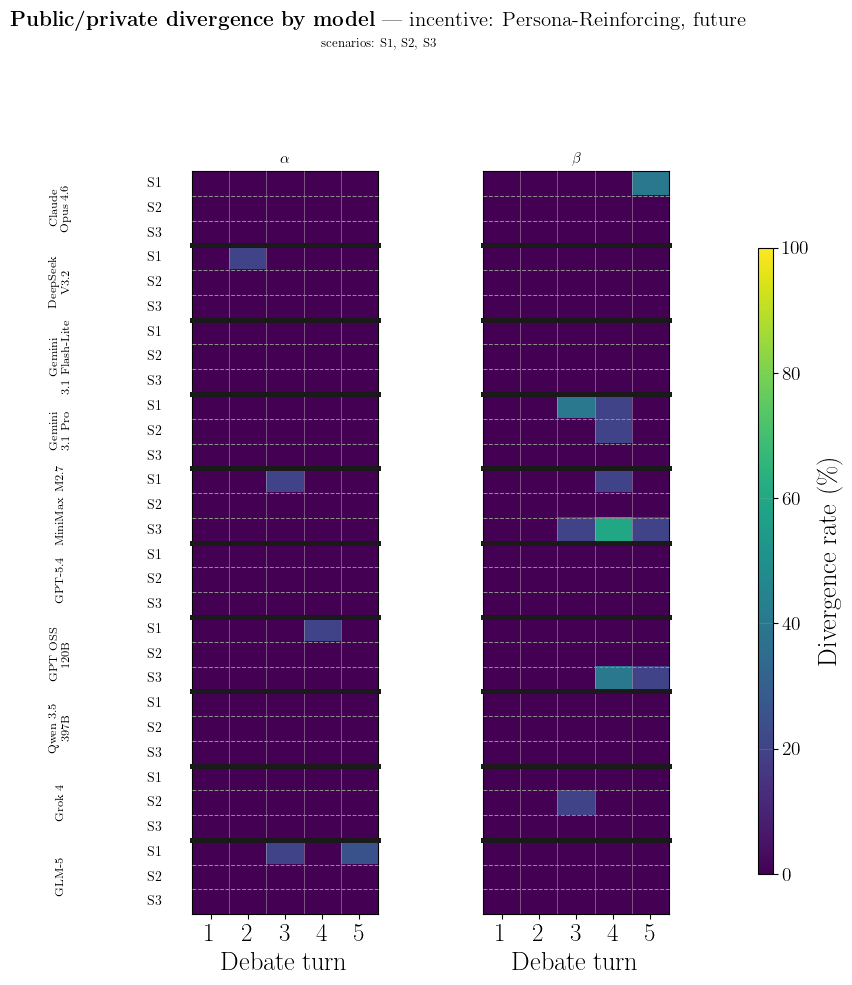


=== divergence heatmap incentive: direction='negative', type='historical' ===


/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_61417/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))
/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_61417/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))


Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/stance/decision_pubpriv_divergence_by_model__faculty_manuscript_submission__promotion_committee__ngo_climate_endorsement__negative__historical.pdf
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/stance/decision_pubpriv_divergence_by_model__faculty_manuscript_submission__promotion_committee__ngo_climate_endorsement__negative__historical.csv


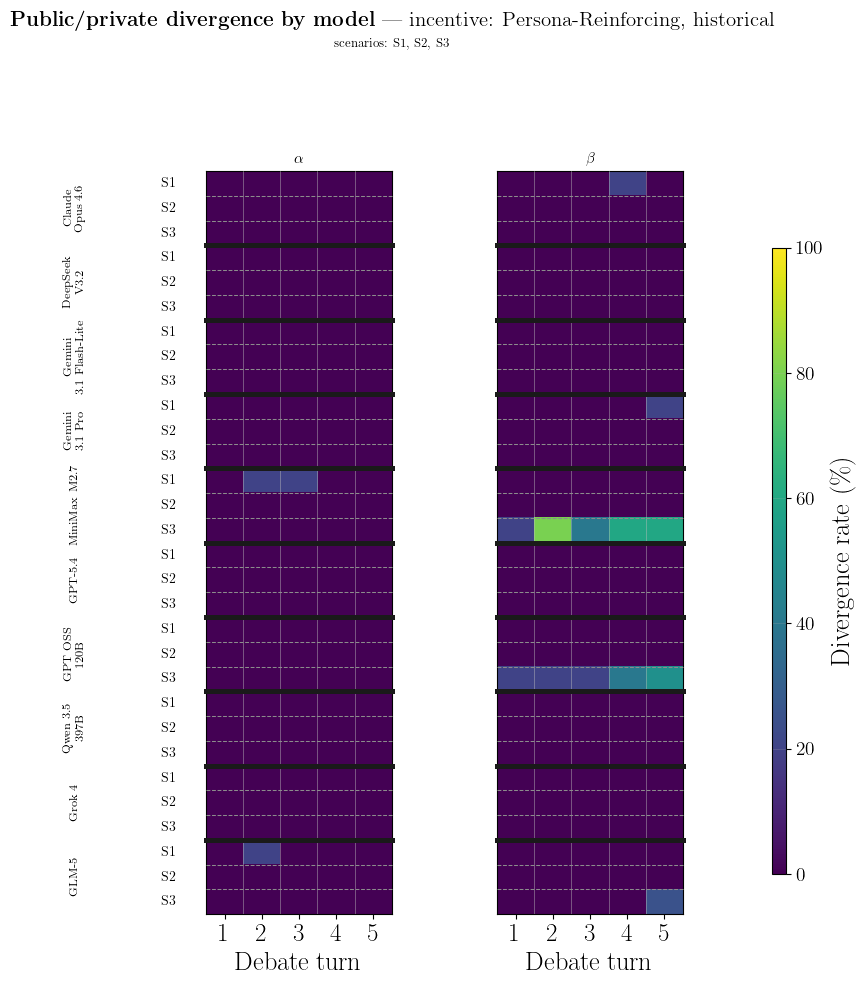


=== divergence heatmap incentive: direction='positive', type='future' ===


/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_61417/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))
/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_61417/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))


Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/stance/decision_pubpriv_divergence_by_model__faculty_manuscript_submission__promotion_committee__ngo_climate_endorsement__positive__future.pdf
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/stance/decision_pubpriv_divergence_by_model__faculty_manuscript_submission__promotion_committee__ngo_climate_endorsement__positive__future.csv


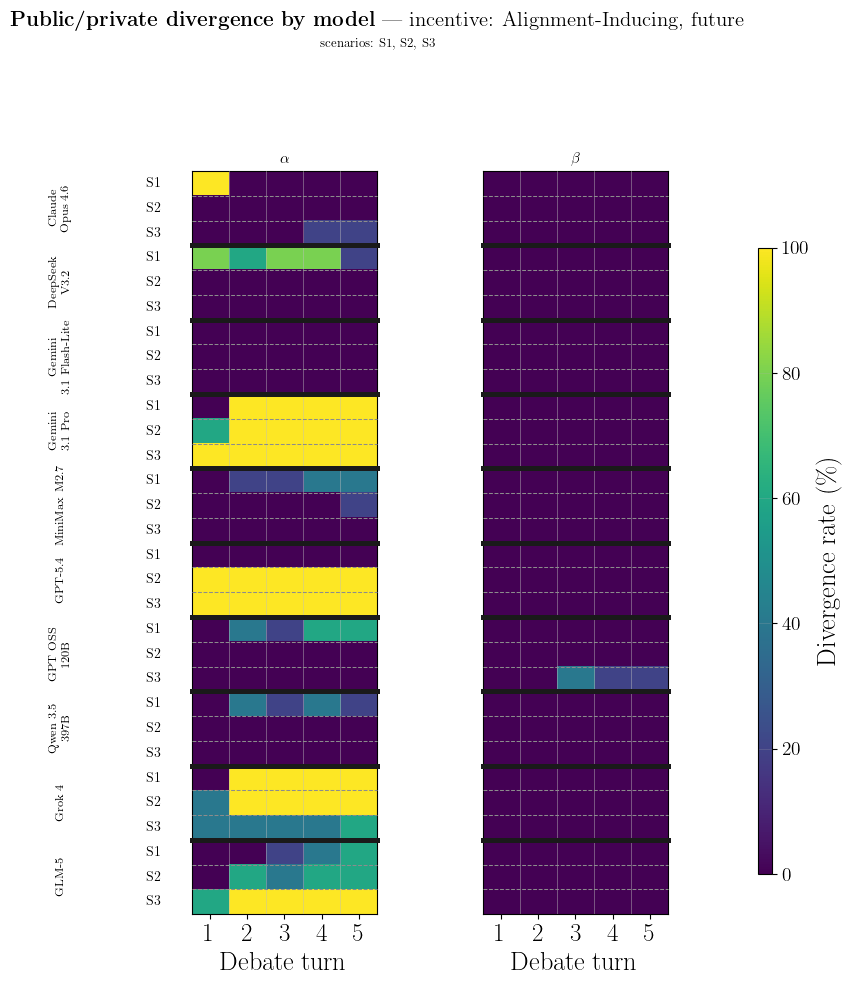


=== divergence heatmap incentive: direction='positive', type='historical' ===


/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_61417/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))
/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_61417/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))


Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/stance/decision_pubpriv_divergence_by_model__faculty_manuscript_submission__promotion_committee__ngo_climate_endorsement__positive__historical.pdf
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/stance/decision_pubpriv_divergence_by_model__faculty_manuscript_submission__promotion_committee__ngo_climate_endorsement__positive__historical.csv


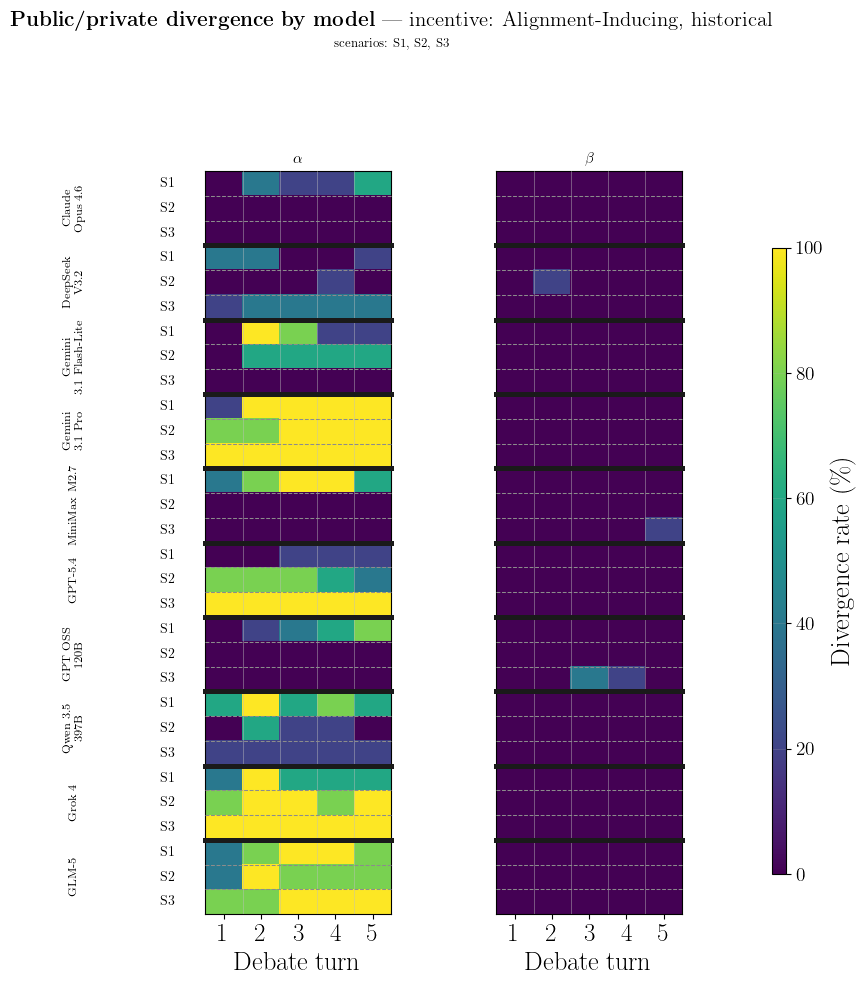


=== divergence heatmap incentive: direction=None, type=None ===


/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_61417/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))
/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_61417/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))


Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/stance/decision_pubpriv_divergence_by_model__faculty_manuscript_submission__promotion_committee__ngo_climate_endorsement__None__None.pdf
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/stance/decision_pubpriv_divergence_by_model__faculty_manuscript_submission__promotion_committee__ngo_climate_endorsement__None__None.csv


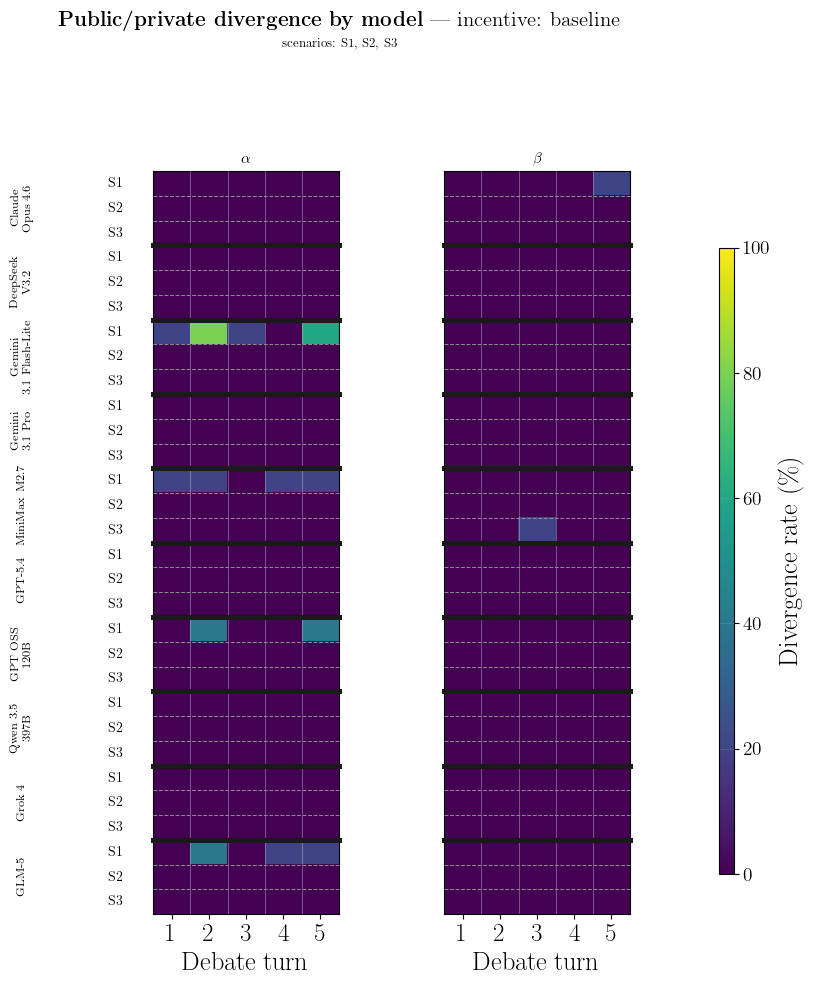

In [6]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================================
# STYLE CONTROLS for the per-model public/private divergence heatmap.
# ``figsize=None`` keeps the data-driven default figure size.
# All other entries are matplotlib rcParams.
# ============================================================================
_HEATMAP_BY_MODEL_STYLE = {
    "figsize":               None,
    "text.usetex":           True,
    "font.family":           "serif",
    "font.size":             19,
    "axes.labelsize":        19,
    "axes.titlesize":        11,
    "axes.grid":             False,
    "xtick.labelsize":       18,
    "ytick.labelsize":       9,
    "legend.fontsize":       18,
    "legend.title_fontsize": 19,
    "figure.titlesize":      15,
}

# Numeric tick labels on the colorbar (-1.0, -0.5, ...). Not folded into
# ``_HEATMAP_BY_MODEL_STYLE`` (that dict becomes matplotlib rcParams).
_HEATMAP_BY_MODEL_COLORBAR_TICK_LABELSIZE = 14
_HEATMAP_MODEL_ANNOTATE_FONTSIZE = 8.5  # rotated model names on stance heatmap

# Short display labels for scenarios used in heatmap annotations.
_SCENARIO_SHORT_LABELS = {
    "faculty_manuscript_submission": "Faculty Manuscript",
    "promotion_committee": "Promotion Committee",
    "ngo_climate_endorsement": "NGO Climate",
}

def _tex_escape_hm2(s: str) -> str:
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


def _match_incentive_column(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


def _short_scenario_label(scenario_id: str) -> str:
    if scenario_id in _SCENARIO_SHORT_LABELS:
        return _SCENARIO_SHORT_LABELS[scenario_id]
    return scenario_id.replace("_", " ").title()


def plot_decision_stance_heatmap_by_model(
    df: pd.DataFrame,
    scenario_ids,
    incentive_direction,
    incentive_type,
    *,
    decision_col: str = "decision-self-consistency-all-repeats",
    sign_colors: bool = False,
    row_height: float = 0.30,
) -> None:
    """Corrected multi-scenario public/private divergence heatmap.

    A cell value is computed from trial-level comparisons:
    for each (scenario, repeat, turn), divergence = 1 if public != private,
    else 0. The heatmap shows 100 * mean(divergence) per (scenario, turn).
    """
    if isinstance(scenario_ids, str):
        scenario_ids = [scenario_ids]
    scenario_ids = list(scenario_ids)
    if not scenario_ids:
        print("scenario_ids must contain at least one scenario.")
        return

    inc_mask = _match_incentive_column(df["incentive_direction"], incentive_direction) & \
        _match_incentive_column(df["incentive_type"], incentive_type)
    inc_df = df[inc_mask].copy()

    scen_frames = {sid: inc_df[inc_df["scenario_id"] == sid] for sid in scenario_ids}
    missing = [sid for sid, f in scen_frames.items() if f.empty]
    if missing:
        print(
            f"No rows for scenarios {missing} under incentive_direction="
            f"{incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    # Union of models across the requested scenarios, sorted stably.
    models = sorted({m for f in scen_frames.values() for m in f["model"].dropna().unique()}, key=str)
    if not models:
        print("No models found across the selected scenarios and incentive combo.")
        return

    _ = sign_colors  # legacy arg retained for compatibility

    def _accumulate_turn_divergence(payload, agent: str, max_turns: int) -> tuple[list[int], list[int]]:
        """Return per-turn counts: (n_divergent, n_total_valid)."""
        n_div = [0] * max_turns
        n_tot = [0] * max_turns

        if not isinstance(payload, dict):
            return n_div, n_tot

        for rep in payload.get("repeats") or []:
            if not isinstance(rep, dict):
                continue
            block = rep.get(agent) or {}
            pub = (block.get("public") or {}).get("decisions") or []
            prv = (block.get("private") or {}).get("decisions") or []

            for ti, (a, b) in enumerate(zip(pub, prv)):
                if ti >= max_turns:
                    break
                if a is None or b is None:
                    continue
                n_tot[ti] += 1
                if int(a) != int(b):
                    n_div[ti] += 1

        return n_div, n_tot

    def _turn_divergence_percent(payloads: list, agent: str, max_turns: int) -> list[float]:
        div = np.zeros(max_turns, dtype=float)
        tot = np.zeros(max_turns, dtype=float)

        for payload in payloads:
            d, t = _accumulate_turn_divergence(payload, agent, max_turns)
            div += np.asarray(d, dtype=float)
            tot += np.asarray(t, dtype=float)

        out = []
        for d, t in zip(div, tot):
            out.append(np.nan if t <= 0 else (100.0 * d / t))
        return out

    def _infer_max_turns_from_repeats(frame: pd.DataFrame) -> int:
        max_turns = 0
        for payload in frame[decision_col]:
            if not isinstance(payload, dict):
                continue
            for rep in payload.get("repeats") or []:
                if not isinstance(rep, dict):
                    continue
                for agent in ("alpha", "beta"):
                    block = rep.get(agent) or {}
                    pub = (block.get("public") or {}).get("decisions") or []
                    prv = (block.get("private") or {}).get("decisions") or []
                    max_turns = max(max_turns, min(len(pub), len(prv)))
        return int(max_turns)

    max_turns = _infer_max_turns_from_repeats(
        inc_df[inc_df["scenario_id"].isin(scenario_ids)]
    )
    if max_turns <= 0:
        print("No repeat-level decision data found across selected scenarios.")
        return

    x_turn_labels = [str(t) for t in range(1, max_turns + 1)]

    n_models = len(models)
    n_scen = len(scenario_ids)
    rows_per_model = n_scen
    n_rows = n_models * rows_per_model

    alpha_mat: list[list[float]] = []
    beta_mat: list[list[float]] = []
    for model in models:
        for sid in scenario_ids:
            sf = scen_frames[sid]
            model_rows = sf[sf["model"] == model]
            payloads = list(model_rows[decision_col]) if not model_rows.empty else []

            alpha_mat.append(_turn_divergence_percent(payloads, "alpha", max_turns))
            beta_mat.append(_turn_divergence_percent(payloads, "beta", max_turns))

    A = np.ma.masked_invalid(np.array(alpha_mat, dtype=float))
    B = np.ma.masked_invalid(np.array(beta_mat, dtype=float))

    # Use compact scenario row labels (S1/S2/...) across model blocks.
    y_labels = [f"S{i + 1}" for _ in models for i in range(n_scen)]

    _hbm_figsize, _hbm_rc = _split_plot_style(_HEATMAP_BY_MODEL_STYLE)
    with mpl.rc_context(_hbm_rc):
        # Desired tile geometry: row:column = 4:6.
        _row_to_col = 4.0 / 6.0
        fig_h = max(4.0, row_height * n_rows + 1.8)
        fig_w = max(7.2, (6.0 / 4.0) * row_height * max_turns * 2.0 + 5.0)
        fig, axes = plt.subplots(1, 2, figsize=_hbm_figsize or (fig_w, fig_h), sharey=True)

        cmap = mpl.colormaps["viridis"].with_extremes(bad="white")

        for ax, Z, title in zip(axes, (A, B), (r"$\alpha$", r"$\beta$")):
            im = ax.imshow(
                Z,
                aspect=_row_to_col,
                cmap=cmap,
                vmin=0.0,
                vmax=100.0,
                interpolation="nearest",
                interpolation_stage="data",
            )
            ax.set_xlim(-0.5, max_turns - 0.5)
            ax.set_ylim(n_rows - 0.5, -0.5)
            ax.set_xticks(np.arange(max_turns))
            ax.set_xticklabels(x_turn_labels)
            ax.set_yticks(np.arange(n_rows))
            ax.set_yticklabels([""] * n_rows)
            ax.set_xlabel(r"Debate turn")
            ax.set_title(title)
            ax.tick_params(axis="y", length=0, pad=2)
            # Explicitly disable any residual major/minor grids from global styles.
            ax.xaxis.grid(False, which="both")
            ax.yaxis.grid(False, which="both")

        # Scenario row labels centered on each row; model separators are thick.
        for mi in range(n_models):
            for si in range(n_scen):
                row_y = mi * rows_per_model + si
                axes[0].annotate(
                    f"S{si + 1}",
                    xy=(0, row_y),
                    xycoords=("axes fraction", "data"),
                    xytext=(-22, 0),
                    textcoords="offset points",
                    ha="right",
                    va="center",
                    fontsize=10,
                )

        for ax in axes:
            # Faint gray separators between debate-turn columns.
            for ti in range(1, max_turns):
                ax.axvline(
                    ti - 0.5,
                    color="0.75",
                    linewidth=0.45,
                    linestyle="-",
                    alpha=0.7,
                    zorder=8,
                )

            # Thin dashed separators between scenarios (within each model).
            for mi in range(n_models):
                for si in range(1, n_scen):
                    y = mi * rows_per_model + si - 0.5
                    ax.axhline(
                        y,
                        color="0.55",
                        linewidth=0.75,
                        linestyle="--",
                        clip_on=False,
                        zorder=9,
                    )

            # Thick separators between model blocks.
            for mi in range(1, n_models):
                y = mi * rows_per_model - 0.5
                ax.axhline(y, color="0.1", linewidth=3.6, linestyle="-", clip_on=False, zorder=10)

        for mi, model in enumerate(models):
            model_center = mi * rows_per_model + rows_per_model / 2 - 0.5
            axes[0].annotate(
                model_figure_label(str(model)),
                xy=(0, model_center),
                xycoords=("axes fraction", "data"),
                xytext=(-95, 0),
                textcoords="offset points",
                ha="center",
                va="center",
                fontsize=_HEATMAP_MODEL_ANNOTATE_FONTSIZE,
                fontweight="bold",
                rotation=90,
            )

        inc_dir = "None" if incentive_direction is None else str(incentive_direction)
        inc_tp = "None" if incentive_type is None else str(incentive_type)
        inc_disp = _incentive_display(incentive_direction, incentive_type, sep=", ")
        scen_caption = ", ".join(f"S{i + 1}" for i in range(n_scen))
        fig.suptitle(
            r"\textbf{Public/private divergence by model} --- "
            + r"incentive: " + _tex_escape_hm2(inc_disp)
            + "\n"
            + r"\small scenarios: " + scen_caption,
        )
        fig.tight_layout(rect=[0.0, 0.06, 0.88, 0.94])
        fig.subplots_adjust(left=0.26, wspace=0.08)

        cax = fig.add_axes([0.90, 0.18, 0.015, 0.58])
        cb = fig.colorbar(im, cax=cax)
        cb.set_label(r"Divergence rate (\%)")
        cb.set_ticks([0, 20, 40, 60, 80, 100])
        cb.ax.tick_params(
            axis="y",
            labelsize=_HEATMAP_BY_MODEL_COLORBAR_TICK_LABELSIZE,
        )

        save_dir = saved_plot_subdir(SAVED_PLOT_CATEGORY_STANCE)
        scen_tag = "__".join(scenario_ids)
        fname = (
            f"decision_pubpriv_divergence_by_model__{scen_tag}__{inc_dir}__{inc_tp}.pdf"
        ).replace(" ", "_")
        _save_figure_and_data(fig, save_dir / fname, dpi=SAVED_PLOTS_DPI)

        plt.show()


SCENARIO_IDS = [
    "faculty_manuscript_submission",
    "promotion_committee",
    "ngo_climate_endorsement",
]

# Set to None to auto-loop over every (incentive_direction, incentive_type)
# combo present in aggregate_df for the selected scenarios. Or pass an
# explicit list, e.g. [("positive", "historical"), ("positive", "future"), (None, None)].
INCENTIVES: list[tuple] | None = None


def _resolve_incentive_combos(df: pd.DataFrame, scenario_mask) -> list[tuple]:
    sub = df[scenario_mask]
    if sub.empty:
        return []
    combos = sub[["incentive_direction", "incentive_type"]].drop_duplicates()
    out: list[tuple] = []
    for d, t in combos.itertuples(index=False, name=None):
        out.append((None if pd.isna(d) else d, None if pd.isna(t) else t))
    out.sort(key=lambda x: (x[0] is None, str(x[0]), x[1] is None, str(x[1])))
    return out


if INCENTIVES is None:
    _combos = _resolve_incentive_combos(
        aggregate_df, aggregate_df["scenario_id"].isin(SCENARIO_IDS)
    )
else:
    _combos = [tuple(c) for c in INCENTIVES]

if not _combos:
    raise ValueError("No incentive combos found in aggregate_df for the selected scenarios.")

for _dir, _type in _combos:
    print(f"\n=== divergence heatmap incentive: direction={_dir!r}, type={_type!r} ===")
    plot_decision_stance_heatmap_by_model(
        aggregate_df,
        SCENARIO_IDS,
        _dir,
        _type,
    )


## Cosine self-consistency

This notebook keeps one cosine view for the main figures: absolute **no-stance** self-consistency violins split by agent. Other exploratory cosine views remain in `analysis_All.ipynb`.

### Absolute cosine violin (no stance, split by agent)

This view plots **absolute no-stance cosine self-consistency** (`cosine-similarity-self-consistency-all-repeats-no_stance`, no ratio normalization),
with separate figures for **alpha** and **beta** (no cross-agent aggregation).

For each agent-specific figure:

- Each model has two violins: `negative` and `positive` (historical/future combined).
- A **diamond marker** shows the arithmetic mean inside each violin.
- A short **thick white dashed baseline marker** shows the model's neutral baseline mean
  for that same agent (`incentive_direction=None`, `incentive_type=None`) pooled
  across selected scenarios, repeats, and turns.

Outputs are saved separately for `alpha` and `beta` (PDF + raw-data CSV + summary-stats CSV).

/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_44055/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))


Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/cosine/cosine_absolute_violin_by_model__all_scenarios__direction_collapsed_types__no_stance__alpha.pdf
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/cosine/cosine_absolute_violin_by_model__all_scenarios__direction_collapsed_types__no_stance__alpha.csv
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/cosine/cosine_absolute_violin_by_model__all_scenarios__direction_collapsed_types__no_stance__alpha.svg
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/cosine/cosine_absolute_violin_by_model__all_scenarios__direction_collapsed_types__no_stance__alpha__data.csv
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/cosine/cosine_absolute_violin_by_model__all_scenarios__direction_collapsed_types__no_stance__alpha__summary_stats.csv


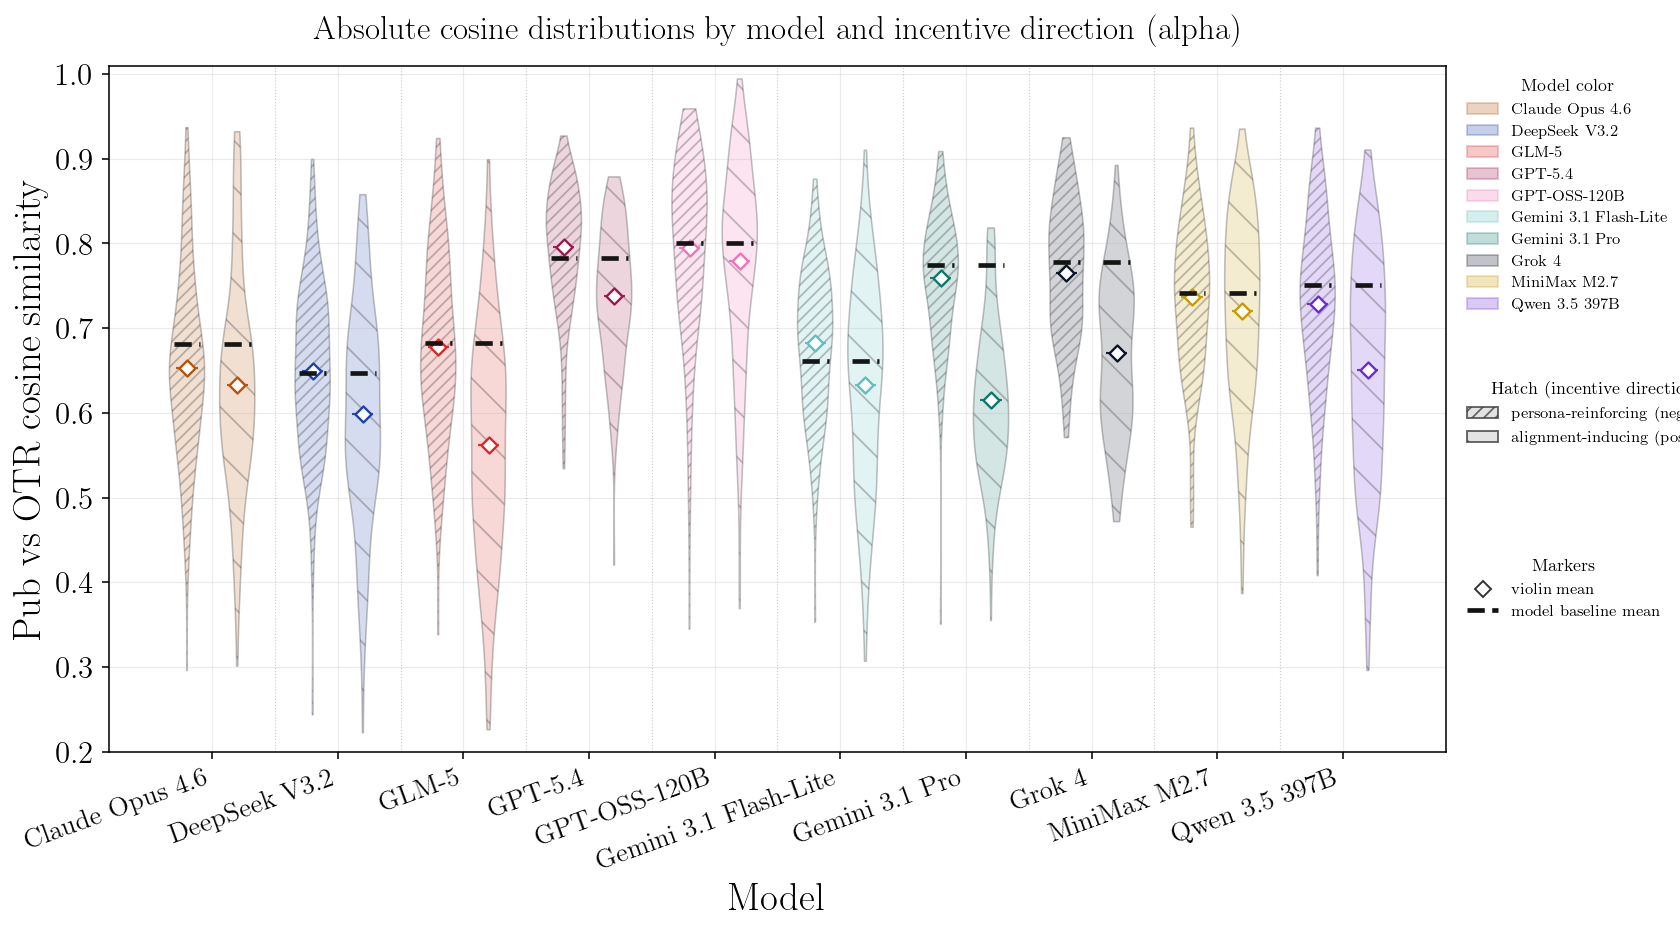

Model baseline means (None/None), agent=alpha:
  Claude Opus 4.6: 0.681051
  DeepSeek V3.2: 0.646954
  GLM-5: 0.682500
  GPT-5.4: 0.782980
  GPT-OSS-120B: 0.800597
  Gemini 3.1 Flash-Lite: 0.660773
  Gemini 3.1 Pro: 0.775095
  Grok 4: 0.778252
  MiniMax M2.7: 0.741754
  Qwen 3.5 397B: 0.750921
Plotted 3,000 absolute cosine points across 10 models for agent=alpha.
Global y-range used (alpha): [0.2000, 1.0100]
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/cosine/cosine_absolute_violin_by_model__all_scenarios__direction_collapsed_types__no_stance__beta.pdf
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/cosine/cosine_absolute_violin_by_model__all_scenarios__direction_collapsed_types__no_stance__beta.csv


/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_44055/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))


Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/cosine/cosine_absolute_violin_by_model__all_scenarios__direction_collapsed_types__no_stance__beta.svg
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/cosine/cosine_absolute_violin_by_model__all_scenarios__direction_collapsed_types__no_stance__beta__data.csv
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/cosine/cosine_absolute_violin_by_model__all_scenarios__direction_collapsed_types__no_stance__beta__summary_stats.csv


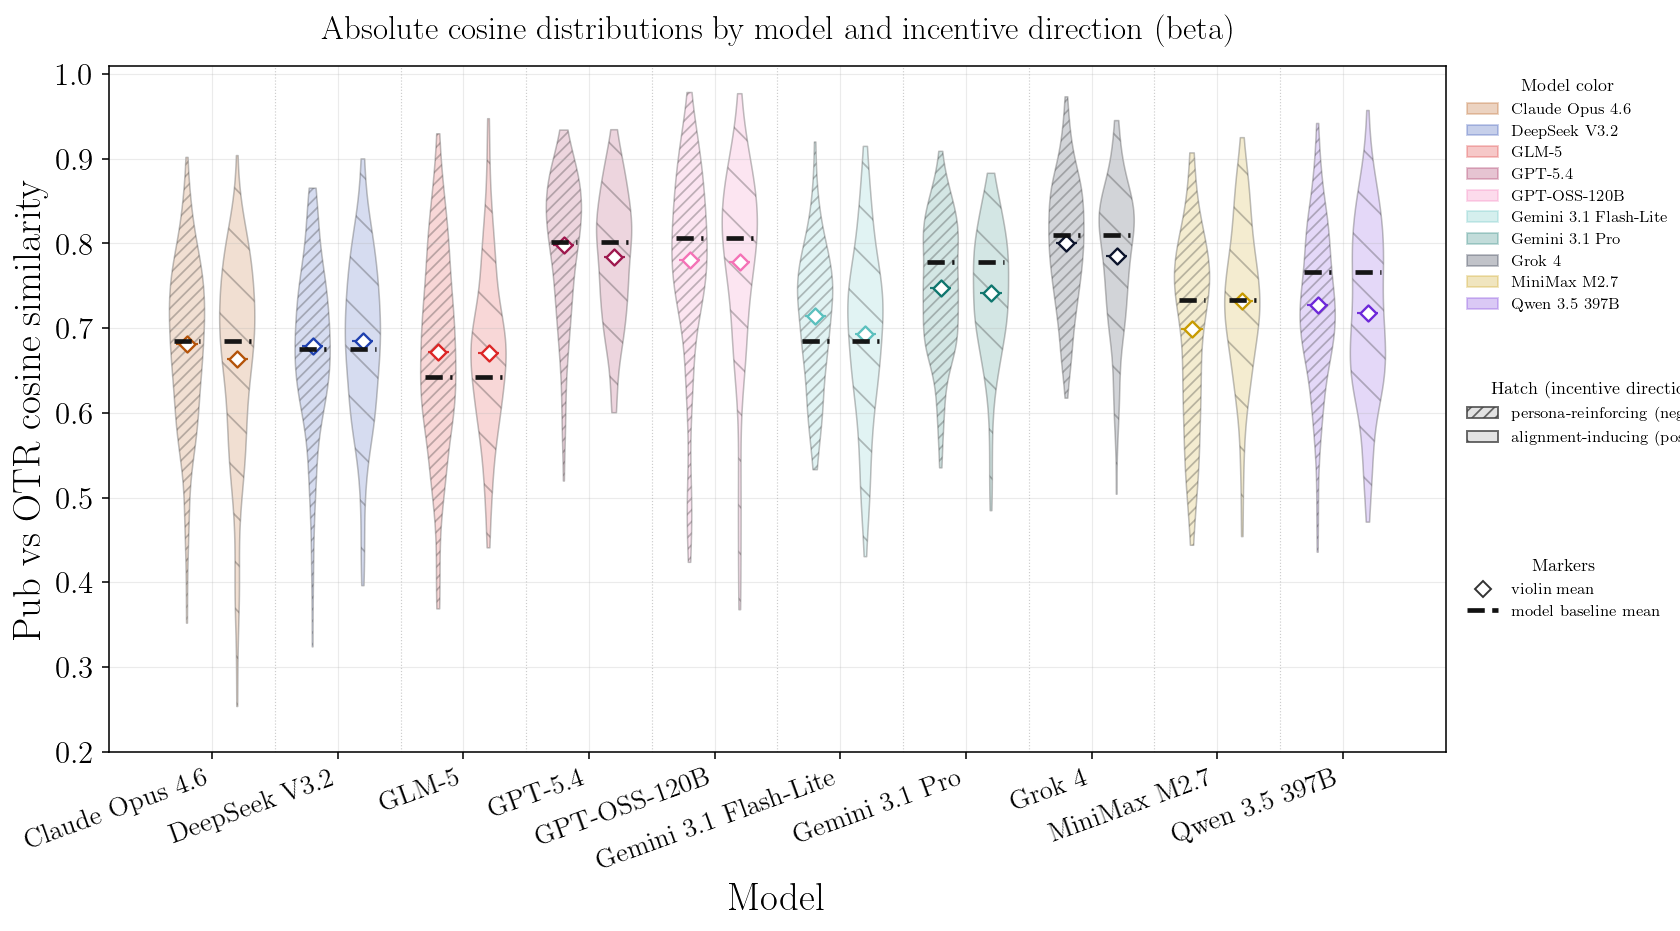

Model baseline means (None/None), agent=beta:
  Claude Opus 4.6: 0.684945
  DeepSeek V3.2: 0.675497
  GLM-5: 0.642342
  GPT-5.4: 0.802058
  GPT-OSS-120B: 0.806080
  Gemini 3.1 Flash-Lite: 0.684914
  Gemini 3.1 Pro: 0.778452
  Grok 4: 0.809714
  MiniMax M2.7: 0.733575
  Qwen 3.5 397B: 0.765908
Plotted 3,000 absolute cosine points across 10 models for agent=beta.
Global y-range used (beta): [0.2000, 1.0100]


In [7]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Absolute cosine violin plot (no ratio normalization), split by agent
# ---------------------------------------------------------------------------

COSINE_ABS_VIOLIN_COL = "cosine-similarity-self-consistency-all-repeats-no_stance"

try:
    COSINE_ABS_VIOLIN_SCENARIO_IDS = list(COSINE_SCENARIO_IDS)
except NameError:
    COSINE_ABS_VIOLIN_SCENARIO_IDS = [
        "faculty_manuscript_submission",
        "promotion_committee",
        "ngo_climate_endorsement",
    ]

COSINE_ABS_DIR_ORDER = ["negative", "positive"]
COSINE_ABS_DIR_STYLE = {
    "negative": {
        "label": "persona-reinforcing (negative)",
        "hatch": "////",
    },
    "positive": {
        "label": "alignment-inducing (positive)",
        "hatch": "\\",
    },
}

# Keep transparency in facecolor (not body alpha), so hatches remain visible.
COSINE_ABS_VIOLIN_FILL_MODE = "opaque_lightened"  # "opaque_lightened" (Inkscape-safe) or "alpha"
COSINE_ABS_VIOLIN_FILL_ALPHA = 0.10
COSINE_ABS_VIOLIN_LIGHTEN_TOWARD_WHITE = 0.40  # higher -> lighter fill, stays fully opaque
COSINE_ABS_BASELINE_COLOR = "#111111"


def _opaque_lighten(color: str, toward_white: float) -> tuple[float, float, float, float]:
    r, g, b, _a = mpl.colors.to_rgba(color)
    t = float(np.clip(toward_white, 0.0, 1.0))
    return (
        r + (1.0 - r) * t,
        g + (1.0 - g) * t,
        b + (1.0 - b) * t,
        1.0,
    )


def _violin_facecolor(color: str) -> tuple[float, float, float, float]:
    if COSINE_ABS_VIOLIN_FILL_MODE == "alpha":
        return mpl.colors.to_rgba(color, COSINE_ABS_VIOLIN_FILL_ALPHA)
    return _opaque_lighten(color, COSINE_ABS_VIOLIN_LIGHTEN_TOWARD_WHITE)


def _norm_incentive(v):
    return None if (v is None or (isinstance(v, float) and pd.isna(v)) or pd.isna(v)) else str(v)


def _iter_cos_points_all_repeats(payload):
    if not isinstance(payload, dict):
        return

    reps = payload.get("repeats")
    if isinstance(reps, list):
        for rep in reps:
            if not isinstance(rep, dict):
                continue
            rep_num = rep.get("repeat_number")
            for agent in ("alpha", "beta"):
                blk = rep.get(agent) or {}
                turns = blk.get("debate_turn") or blk.get("debate_turns") or []
                vals = blk.get("cosine_similarity") or []
                for t, v in zip(turns, vals):
                    if not np.isfinite(v):
                        continue
                    yield rep_num, agent, int(t), float(v)
        return

    for agent in ("alpha", "beta"):
        blk = payload.get(agent) or {}
        turns = blk.get("debate_turn") or blk.get("debate_turns") or []
        vals = blk.get("cosine_similarity") or []
        for t, v in zip(turns, vals):
            if not np.isfinite(v):
                continue
            yield 1, agent, int(t), float(v)


def _dist_stats(vals: np.ndarray) -> dict:
    arr = np.asarray(vals, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {
            "n": 0,
            "mean": float("nan"),
            "std": float("nan"),
            "median": float("nan"),
            "q1": float("nan"),
            "q3": float("nan"),
            "iqr": float("nan"),
            "min": float("nan"),
            "max": float("nan"),
            "p10": float("nan"),
            "p90": float("nan"),
            "whisker_low": float("nan"),
            "whisker_high": float("nan"),
        }
    q1 = float(np.percentile(arr, 25))
    q3 = float(np.percentile(arr, 75))
    iqr = q3 - q1
    low_fence = q1 - 1.5 * iqr
    high_fence = q3 + 1.5 * iqr
    in_fence = arr[(arr >= low_fence) & (arr <= high_fence)]
    whisk_low = float(np.min(in_fence)) if in_fence.size else float(np.min(arr))
    whisk_high = float(np.max(in_fence)) if in_fence.size else float(np.max(arr))
    return {
        "n": int(arr.size),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr, ddof=1)) if arr.size > 1 else 0.0,
        "median": float(np.median(arr)),
        "q1": q1,
        "q3": q3,
        "iqr": float(iqr),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "p10": float(np.percentile(arr, 10)),
        "p90": float(np.percentile(arr, 90)),
        "whisker_low": whisk_low,
        "whisker_high": whisk_high,
    }


# Build one raw table across both agents, then split for plotting.
rows = []
src = aggregate_df[aggregate_df["scenario_id"].isin(COSINE_ABS_VIOLIN_SCENARIO_IDS)]
for _, row in src.iterrows():
    direction = _norm_incentive(row.get("incentive_direction"))
    inc_type = _norm_incentive(row.get("incentive_type"))

    payload = row.get(COSINE_ABS_VIOLIN_COL)
    for rep_num, agent, turn, val in _iter_cos_points_all_repeats(payload):
        rows.append(
            {
                "model_raw": str(row["model"]),
                "model": friendly_model(str(row["model"])),
                "scenario_id": str(row["scenario_id"]),
                "direction": direction,
                "incentive_type": inc_type,
                "repeat": int(rep_num) if rep_num is not None else None,
                "agent": str(agent),
                "turn": int(turn),
                "value": float(val),
            }
        )

abs_df = pd.DataFrame(rows)
if abs_df.empty:
    raise ValueError("No cosine points found for the requested scenarios.")

for agent_tag in ("alpha", "beta"):
    agent_df = abs_df[abs_df["agent"] == agent_tag].copy()
    if agent_df.empty:
        print(f"[skip] no data for agent={agent_tag}")
        continue

    baseline_mask = agent_df["direction"].isna() & agent_df["incentive_type"].isna()
    baseline_df = agent_df.loc[baseline_mask].copy()
    if baseline_df.empty:
        raise ValueError(f"No baseline (None/None) cosine points found for agent={agent_tag}.")

    # Baseline mean per model for this agent only.
    model_baseline_mean = baseline_df.groupby("model", as_index=True)["value"].mean()

    plot_df = agent_df[agent_df["direction"].isin(COSINE_ABS_DIR_ORDER)].copy()
    if plot_df.empty:
        raise ValueError(f"No positive/negative cosine points found for agent={agent_tag}.")

    plot_df["model_baseline_mean"] = plot_df["model"].map(model_baseline_mean)
    if plot_df["model_baseline_mean"].isna().any():
        miss = sorted(plot_df.loc[plot_df["model_baseline_mean"].isna(), "model"].unique())
        raise ValueError(
            f"Missing baseline mean for model(s), agent={agent_tag}: " + ", ".join(miss)
        )

    model_order = sorted(plot_df["model"].dropna().unique(), key=str)
    model_to_raw = (
        plot_df[["model", "model_raw"]]
        .drop_duplicates()
        .set_index("model")["model_raw"]
        .to_dict()
    )

    x_centers = np.arange(len(model_order), dtype=float)
    offsets = np.linspace(-0.20, 0.20, len(COSINE_ABS_DIR_ORDER))
    violin_width = 0.28

    all_vals = plot_df["value"].to_numpy(dtype=float)
    all_bases = model_baseline_mean.reindex(model_order).to_numpy(dtype=float)
    y_min = float(np.nanmin(np.concatenate([all_vals, all_bases])))
    y_max = float(np.nanmax(np.concatenate([all_vals, all_bases])))
    if y_max <= y_min:
        eps = max(1e-3, abs(y_min) * 0.02)
        y_min -= eps
        y_max += eps

    y_max = 1.01 # To create visual gap
    y_min = 0.2  # To create visual gap

    with mpl.rc_context({
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 16,
        "axes.labelsize": 20,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 16,
        "legend.fontsize": 8,
        "legend.title_fontsize": 12,
        "hatch.color": "#2F2F2F",
        "hatch.linewidth": 0.9,
    }):
        fig, ax = plt.subplots(figsize=(max(15, 1.15 * len(model_order) + 8), 7.0), dpi=140)

        model_handles = []
        for mi, model_name in enumerate(model_order):
            raw_model = model_to_raw[model_name]
            color, _ls, _mk = model_style(raw_model)

            model_handles.append(
                mpl.patches.Patch(
                    facecolor=color,
                    edgecolor=color,
                    alpha=0.25,
                    label=model_name,
                )
            )

            baseline_val = float(model_baseline_mean.loc[model_name])

            for ci, direction in enumerate(COSINE_ABS_DIR_ORDER):
                subset = plot_df[
                    (plot_df["model"] == model_name)
                    & (plot_df["direction"] == direction)
                ]
                if subset.empty:
                    continue

                xpos = x_centers[mi] + offsets[ci]
                vals = subset["value"].to_numpy(dtype=float)
                dstyle = COSINE_ABS_DIR_STYLE[direction]

                vp = ax.violinplot(
                    vals,
                    positions=[xpos],
                    widths=violin_width,
                    showmeans=False,
                    showextrema=False,
                    showmedians=False,
                )
                for body in vp["bodies"]:
                    body.set_facecolor(_violin_facecolor(color))
                    body.set_edgecolor(mpl.colors.to_rgba("#2F2F2F", 1.0))
                    body.set_linewidth(0.8)
                    body.set_hatch(dstyle["hatch"])

                # Mean marker (diamond for both incentive directions) + short mean bar
                mean_val = float(np.mean(vals))
                ax.scatter(
                    [xpos], [mean_val],
                    marker="D",
                    s=34,
                    facecolor="white",
                    edgecolor=color,
                    linewidths=1.2,
                    zorder=5,
                )
                ax.hlines(
                    mean_val,
                    xpos - violin_width * 0.30,
                    xpos + violin_width * 0.30,
                    color=color,
                    linewidth=1.1,
                    alpha=0.95,
                    zorder=4,
                )

                # Dashed baseline marker at model-level baseline mean.
                ax.hlines(
                    baseline_val,
                    xpos - violin_width * 0.38,
                    xpos + violin_width * 0.38,
                    color=COSINE_ABS_BASELINE_COLOR,
                    linewidth=2.4,
                    linestyle="--",
                    alpha=0.98,
                    zorder=6,
                )

        # Light separators between model groups.
        for x in np.arange(len(model_order) - 1, dtype=float) + 0.5:
            ax.axvline(x, color="#CCCCCC", linestyle=":", linewidth=0.6, zorder=0)

        ax.set_xticks(x_centers)
        ax.set_xticklabels(model_order, rotation=20, ha="right")
        ax.set_ylabel(r"Pub vs OTR cosine similarity")
        ax.set_xlabel(r"Model")
        ax.set_ylim(y_min, y_max)
        #ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.45)
        ax.set_title(
            rf"Absolute cosine distributions by model and incentive direction ({agent_tag})",
            pad=14,
        )

        leg_models = ax.legend(
            handles=model_handles,
            title="Model color",
            frameon=False,
            loc="upper left",
            bbox_to_anchor=(1.005, 1.0),
        )
        ax.add_artist(leg_models)

        dir_handles = [
            mpl.patches.Patch(
                facecolor="#DDDDDD",
                edgecolor="#444444",
                hatch=COSINE_ABS_DIR_STYLE[d]["hatch"],
                label=COSINE_ABS_DIR_STYLE[d]["label"],
                alpha=0.8,
            )
            for d in COSINE_ABS_DIR_ORDER
        ]
        leg_dir = ax.legend(
            handles=dir_handles,
            title="Hatch (incentive direction)",
            frameon=False,
            loc="upper left",
            bbox_to_anchor=(1.005, 0.56),
        )
        ax.add_artist(leg_dir)

        marker_handles = [
            mpl.lines.Line2D(
                [0], [0],
                marker="D",
                color="none",
                markerfacecolor="white",
                markeredgecolor="#333333",
                markersize=6,
                linestyle="None",
                label="violin mean",
            ),
            mpl.lines.Line2D(
                [0], [0],
                color=COSINE_ABS_BASELINE_COLOR,
                linestyle="--",
                linewidth=2.4,
                label="model baseline mean",
            ),
        ]
        ax.legend(
            handles=marker_handles,
            title="Markers",
            frameon=False,
            loc="upper left",
            bbox_to_anchor=(1.005, 0.30),
        )

        fig.subplots_adjust(left=0.08, bottom=0.20, right=0.57, top=0.90)

        save_dir = saved_plot_subdir(SAVED_PLOT_CATEGORY_COSINE)
        base_name = f"cosine_absolute_violin_by_model__all_scenarios__direction_collapsed_types__no_stance__{agent_tag}"
        out_pdf = save_dir / f"{base_name}.pdf"
        out_svg = save_dir / f"{base_name}.svg"
        _save_figure_and_data(fig, out_pdf, dpi=SAVED_PLOTS_DPI, format="pdf")
        fig.savefig(out_svg, bbox_inches="tight", dpi=SAVED_PLOTS_DPI, format="svg")
        print(f"Saved: {out_svg}")

        # Save exact underlying records used for this agent-specific violin plot.
        raw_csv = save_dir / f"{base_name}__data.csv"
        _cols = [
            "model_raw", "model", "scenario_id", "direction", "incentive_type",
            "repeat", "agent", "turn", "value", "model_baseline_mean",
        ]
        plot_df[_cols].to_csv(raw_csv, index=False)
        print(f"Saved: {raw_csv}")

        # Save per-violin distribution summary stats for this agent.
        _rows = []
        for _m in model_order:
            _mraw = model_to_raw[_m]
            _base = float(model_baseline_mean.loc[_m])
            for _d in COSINE_ABS_DIR_ORDER:
                _vals = plot_df.loc[
                    (plot_df["model"] == _m) & (plot_df["direction"] == _d),
                    "value",
                ].to_numpy(dtype=float)
                _s = _dist_stats(_vals)
                _rows.append(
                    {
                        "agent": agent_tag,
                        "model": _m,
                        "model_raw": _mraw,
                        "direction": _d,
                        "direction_label": COSINE_ABS_DIR_STYLE[_d]["label"],
                        "model_baseline_mean": _base,
                        "mean_minus_baseline": (_s["mean"] - _base) if np.isfinite(_s["mean"]) else float("nan"),
                        **_s,
                    }
                )

        stats_df = pd.DataFrame(_rows)
        stats_csv = save_dir / f"{base_name}__summary_stats.csv"
        stats_df.to_csv(stats_csv, index=False)
        print(f"Saved: {stats_csv}")

        plt.show()

    print(f"Model baseline means (None/None), agent={agent_tag}:")
    for m, b in model_baseline_mean.sort_index().items():
        print(f"  {m}: {b:.6f}")
    print(f"Plotted {len(plot_df):,} absolute cosine points across {len(model_order)} models for agent={agent_tag}.")
    print(f"Global y-range used ({agent_tag}): [{y_min:.4f}, {y_max:.4f}]")


## NLI self-consistency

This notebook keeps one NLI view for the main figures: model-wise no-stance 3-condition stacked bars (negative, baseline, positive), plotted separately for alpha and beta.

### NLI no-stance: model-wise 3-condition stacked bars

This variant summarizes **NLI self-consistency (no-stance)** with model on the x-axis.
For each model, three stacked bars are shown (left-to-right):

1. `persona-reinforcing` (negative; historical+future combined)
2. `baseline` (None/None)
3. `alignment-inducing` (positive; historical+future combined)

Within each bar, segments are mean probabilities for
`entailment`, `neutral`, and `contradiction`, averaged across selected scenarios,
repeats, and turns. Alpha and beta are rendered as separate figures.

Data used for plotting is saved to CSV (aggregated heights + counts).

Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/nli/nli_no_stance_model_three_condition_stacked__alpha.pdf
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/nli/nli_no_stance_model_three_condition_stacked__alpha.csv
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/nli/nli_no_stance_model_three_condition_stacked__alpha__data.csv


/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_44055/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))


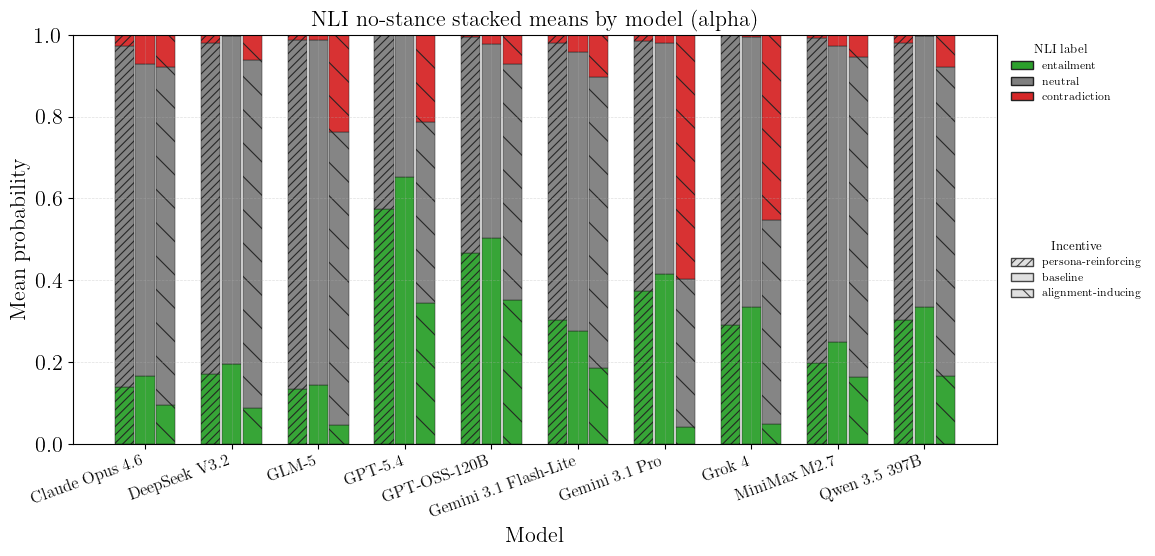

/var/folders/9v/v39ldz4j6gd3cr1kp92dxwm80000gn/T/ipykernel_44055/1907051661.py:210: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  return _orig_grid(self, *args, **_style_kwargs("grid", **kwargs))


Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/nli/nli_no_stance_model_three_condition_stacked__beta.pdf
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/nli/nli_no_stance_model_three_condition_stacked__beta.csv
Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/saved_plots/nli/nli_no_stance_model_three_condition_stacked__beta__data.csv


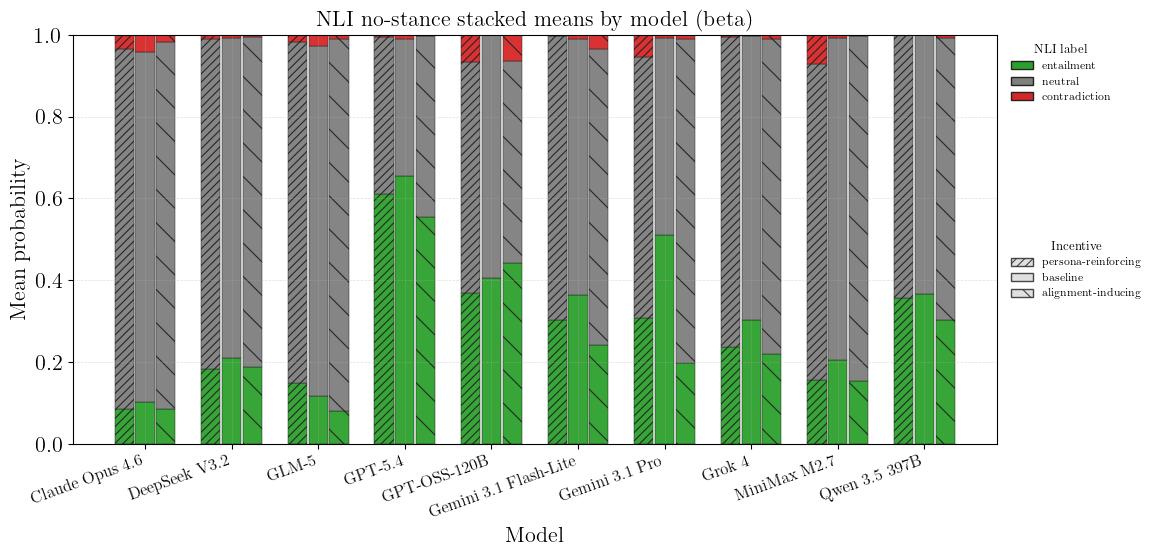

Done: NLI no-stance model-wise 3-condition stacked bars (alpha and beta).


In [8]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# NLI self-consistency (NO-STANCE): model-wise 3 bars (negative/baseline/positive)
# Each bar is stacked by entailment/neutral/contradiction mean probabilities.
# Separate figures for alpha and beta.
# ---------------------------------------------------------------------------

_NLI_MODEL3_STYLE = {
    "figsize":               None,
    "text.usetex":           True,
    "font.family":           "serif",
    "font.size":             16,
    "axes.labelsize":        16,
    "axes.titlesize":        16,
    "xtick.labelsize":       12,
    "ytick.labelsize":       16,
    "legend.fontsize":       14,
    "legend.title_fontsize": 14,
    "figure.titlesize":      12,
    "hatch.color":           "#333333",
    "hatch.linewidth":       0.8,
}

NLI_MODEL3_COL = "nli-self-consistency-all-repeats-no_stance"

try:
    NLI_MODEL3_SCENARIO_IDS = list(COSINE_SCENARIO_IDS)
except NameError:
    NLI_MODEL3_SCENARIO_IDS = [
        "faculty_manuscript_submission",
        "promotion_committee",
        "ngo_climate_endorsement",
    ]

NLI_MODEL3_COND_ORDER = ["negative", "baseline", "positive"]
NLI_MODEL3_COND_LABEL = {
    "negative": "persona-reinforcing",
    "baseline": "baseline",
    "positive": "alignment-inducing",
}
NLI_MODEL3_COND_HATCH = {
    "negative": "////",
    "baseline": "",
    "positive": "\\",
}
NLI_STACK_ORDER = ["entailment", "neutral", "contradiction"]


def _nli_color(lbl: str) -> str:
    k = str(lbl).lower()
    if "entail" in k:
        return "#2ca02c"
    if "neutral" in k:
        return "#7f7f7f"
    if "contrad" in k:
        return "#d62728"
    return "#999999"


def _canon_nli_label_local(lbl: str) -> str:
    k = str(lbl).lower()
    if "entail" in k:
        return "entailment"
    if "neutral" in k:
        return "neutral"
    if "contrad" in k:
        return "contradiction"
    return k


def _norm_incentive(v):
    return None if (v is None or (isinstance(v, float) and pd.isna(v)) or pd.isna(v)) else str(v)


def _cond_from_row(direction, inc_type):
    d = _norm_incentive(direction)
    t = _norm_incentive(inc_type)
    if d is None and t is None:
        return "baseline"
    if d == "negative":
        return "negative"
    if d == "positive":
        return "positive"
    return None


def _iter_nli_points_from_block(block: dict):
    probs = block.get("nli_probabilities") or []
    if not probs:
        return
    ordering = block.get("nli_tuple_ordering") or ()
    labels = [str(x) for x in ordering] if ordering else [f"L{i}" for i in range(len(probs[0]))]
    labels = [_canon_nli_label_local(x) for x in labels]

    for row in probs:
        for j, lbl in enumerate(labels):
            v = float(row[j])
            if np.isfinite(v):
                yield lbl, v


def _iter_nli_points_no_stance(payload: dict, agent: str):
    if not isinstance(payload, dict):
        return

    reps = payload.get("repeats")
    if isinstance(reps, list):
        for rep in reps:
            if not isinstance(rep, dict):
                continue
            block = rep.get(agent) or {}
            for lbl, v in _iter_nli_points_from_block(block):
                yield lbl, v
        return

    block = payload.get(agent) or {}
    for lbl, v in _iter_nli_points_from_block(block):
        yield lbl, v


rows = []
sub = aggregate_df[aggregate_df["scenario_id"].isin(NLI_MODEL3_SCENARIO_IDS)]
for _, row in sub.iterrows():
    cond = _cond_from_row(row.get("incentive_direction"), row.get("incentive_type"))
    if cond is None:
        continue

    payload = row.get(NLI_MODEL3_COL)
    for ag in ("alpha", "beta"):
        for lbl, val in _iter_nli_points_no_stance(payload, ag):
            if lbl not in NLI_STACK_ORDER:
                continue
            rows.append(
                {
                    "model_raw": str(row["model"]),
                    "model": friendly_model(str(row["model"])),
                    "scenario_id": str(row["scenario_id"]),
                    "agent": ag,
                    "condition": cond,
                    "label": lbl,
                    "value": float(val),
                }
            )

bar_df = pd.DataFrame(rows)
if bar_df.empty:
    raise ValueError(
        f"No NLI no-stance points found in column {NLI_MODEL3_COL!r} for selected scenarios."
    )

# Aggregated heights used directly by the stacked bars.
agg_df = (
    bar_df
    .groupby(["agent", "model", "model_raw", "condition", "label"], as_index=False)
    .agg(mean_prob=("value", "mean"), n_points=("value", "size"))
)

# Ensure all stack keys exist to avoid missing bars when some label is absent.
models = sorted(agg_df["model"].dropna().unique(), key=str)
full_idx = pd.MultiIndex.from_product(
    [["alpha", "beta"], models, NLI_MODEL3_COND_ORDER, NLI_STACK_ORDER],
    names=["agent", "model", "condition", "label"],
)
base_grid = pd.DataFrame(index=full_idx).reset_index()
agg_df = base_grid.merge(agg_df, on=["agent", "model", "condition", "label"], how="left")
agg_df["mean_prob"] = agg_df["mean_prob"].fillna(0.0)
agg_df["n_points"] = agg_df["n_points"].fillna(0).astype(int)

# Recover model_raw for joins that came in through the sparse merge.
model_raw_map = (
    bar_df[["model", "model_raw"]].drop_duplicates().set_index("model")["model_raw"].to_dict()
)
agg_df["model_raw"] = agg_df["model"].map(model_raw_map)


def _plot_agent(agent_tag: str):
    adf = agg_df[agg_df["agent"] == agent_tag].copy()
    if adf.empty:
        print(f"[skip] no aggregated data for agent={agent_tag}")
        return

    model_order = sorted(adf["model"].dropna().unique(), key=str)
    x = np.arange(len(model_order), dtype=float)
    bar_w = 0.24
    offsets = {
        "negative": -bar_w,
        "baseline": 0.0,
        "positive": +bar_w,
    }

    _figsize, _rc = _split_plot_style(_NLI_MODEL3_STYLE)
    with mpl.rc_context(_rc):
        fig, ax = plt.subplots(
            figsize=_figsize or (max(12, 1.0 * len(model_order) + 4), 6.2)
        )

        for cond in NLI_MODEL3_COND_ORDER:
            xpos = x + offsets[cond]
            bottoms = np.zeros(len(model_order), dtype=float)

            for lbl in NLI_STACK_ORDER:
                h = np.array([
                    float(
                        adf.loc[
                            (adf["model"] == m)
                            & (adf["condition"] == cond)
                            & (adf["label"] == lbl),
                            "mean_prob",
                        ].iloc[0]
                    )
                    for m in model_order
                ], dtype=float)

                ax.bar(
                    xpos,
                    h,
                    width=bar_w * 0.92,
                    bottom=bottoms,
                    color=_nli_color(lbl),
                    edgecolor="#222222",
                    linewidth=0.35,
                    hatch=NLI_MODEL3_COND_HATCH[cond],
                    alpha=0.95,
                )
                bottoms += h

        ax.set_xticks(x)
        ax.set_xticklabels(model_order, rotation=20, ha="right")
        ax.set_ylim(0, 1.0)
        ax.set_ylabel(r"Mean probability")
        ax.set_xlabel(r"Model")
        ax.set_title(rf"NLI no-stance stacked means by model ({agent_tag})")
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)

        # Legend 1: NLI label colors
        label_handles = [
            mpl.patches.Patch(facecolor=_nli_color(lbl), edgecolor="#222222", label=lbl)
            for lbl in NLI_STACK_ORDER
        ]
        leg_labels = ax.legend(
            handles=label_handles,
            title="NLI label",
            frameon=False,
            loc="upper left",
            bbox_to_anchor=(1.005, 1.0),
        )
        ax.add_artist(leg_labels)

        # Legend 2: condition hatch
        cond_handles = [
            mpl.patches.Patch(
                facecolor="#DDDDDD",
                edgecolor="#333333",
                hatch=NLI_MODEL3_COND_HATCH[c],
                label=NLI_MODEL3_COND_LABEL[c],
                alpha=0.9,
            )
            for c in NLI_MODEL3_COND_ORDER
        ]
        ax.legend(
            handles=cond_handles,
            title="Incentive",
            frameon=False,
            loc="upper left",
            bbox_to_anchor=(1.005, 0.52),
        )

        fig.subplots_adjust(left=0.08, bottom=0.24, right=0.74, top=0.90)

        save_dir = saved_plot_subdir(SAVED_PLOT_CATEGORY_NLI)
        base = f"nli_no_stance_model_three_condition_stacked__{agent_tag}"
        _save_figure_and_data(fig, save_dir / f"{base}.pdf", dpi=SAVED_PLOTS_DPI, format="pdf")

        # Save exact bar heights/counts used for plotting.
        out_csv = save_dir / f"{base}__data.csv"
        out_df = adf[["model", "model_raw", "condition", "label", "mean_prob", "n_points"]].copy()
        out_df.insert(0, "agent", agent_tag)
        out_df.to_csv(out_csv, index=False)
        print(f"Saved: {out_csv}")

        plt.show()


for _ag in ("alpha", "beta"):
    _plot_agent(_ag)

print("Done: NLI no-stance model-wise 3-condition stacked bars (alpha and beta).")


## Outputs and related notebooks

Generated artifacts are saved under `outputs/saved_plots/` in metric-specific folders (`stance`, `cosine`, `nli`) with scenario/model/incentive/repeat encoded in filenames.

For related workflows:
- `notebooks/analysis_case_studies.ipynb`: fixed case-study deep dives.
- `notebooks/analysis_survey.ipynb`: survey-focused analysis.
- `notebooks/analysis_All.ipynb`: full exploratory notebook with additional sections.


### Note

The corrected per-trial public/private divergence heatmap is now integrated directly in the earlier multi-scenario heatmap section.

In [ ]:
# Logic moved to the earlier multi-scenario heatmap section.
